# Rubin DP2 Cutout Mosaics: HST-unresolved / Rubin-resolved COSMOS Sources

RGB cutout mosaics for the objects selected by
`src/extract_hst_unresolved_rubin_resolved.py`: COSMOS sources with
`r_cModelMag < 23` that COSMOS2020 FARMER (HST/ACS) calls **unresolved**
(`ACS_MU_CLASS = 2`) but Rubin DP2 calls **extended** (`refExtendedness = 1`).

**Run on the RSP.** `deep_coadd` pixel data lives only in the Rubin Butler repo.

### DP2 image API notes

DP2 (Science Pipelines v30) changed the image stack relative to DP1/DP0:

| | DP1 / DP0 (v29 and earlier) | **DP2 (v30)** |
|---|---|---|
| dataset type | `deepCoadd` | `deep_coadd` |
| storage class | `ExposureF` | `CellCoadd` |
| geometry | `lsst.geom` `Box2I`/`ExtentI` | `lsst.images` `Box`/`Interval` |
| sky->pixel | `exposure.getWcs().skyToPixel()` | `sky_projection.sky_to_pixel()` |
| patch lookup | `skymap.findTract(...)` | `butler.query_datasets(..., OVERLAPS POINT)` |

This notebook uses the DP2 forms throughout. `image.array` is a plain numpy
array; `.to_legacy()` is only needed to hand an image to `afw_display`.

Because ~99% of this sample is `detect_fromBlend`, stamp titles carry the
blend/isolation flags and `psf - cModel`, so deblending failures can be told
apart from genuine HST/Rubin disagreements by eye.

**Run the single-object test in section 6 before the full loop.**

## 1. Setup

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.visualization import make_lupton_rgb

from lsst.daf.butler import Butler
from lsst.images import Box

## 2. Configuration

`Butler('dp2', collections="dp2")` is the form used by the current official DP2
tutorial notebooks. If you would rather read the same processing run your
catalog was exported from (`dumpCatalog.ipynb` used the `dp2_prep` preparation
repo), set the repo/collection accordingly - but note the published `dp2` repo
is the supported path, and cutouts should correspond to the catalog either way
for the object positions used here.

In [2]:
# --- Butler ------------------------------------------------------------------
BUTLER_REPO = "dp2"
COLLECTION = "dp2"
COADD_DATASET_TYPE = "deep_coadd"    # DP2/v30 name (DP1 and earlier: "deepCoadd")

# --- Input / output ----------------------------------------------------------
CSV_PATH = "cosmos_hst_unresolved_rubin_resolved.csv"
OUTPUT_FOLDER = "cutout_mosaics"

# --- Cutout geometry ---------------------------------------------------------
STAMP_ARCSEC = 10.0
PIXEL_SCALE = 0.2                    # arcsec/pixel, LSSTCam
HALF_PIX = int(round(STAMP_ARCSEC / PIXEL_SCALE)) // 2   # padding each side

# --- Mosaic layout -----------------------------------------------------------
GRID = 5                             # GRID x GRID stamps per page
N_OBJECTS = None                     # None = all; e.g. 25 for a quick look

# --- RGB rendering -----------------------------------------------------------
RGB_BANDS = ("i", "r", "g")          # -> R, G, B
LUPTON_STRETCH = 5.0                 # tune using the test cell in section 6
LUPTON_Q = 8.0

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
print(f"Stamp: {2 * HALF_PIX + 1} pix = {(2 * HALF_PIX + 1) * PIXEL_SCALE:.1f} arcsec")

Stamp: 51 pix = 10.2 arcsec


## 3. Connect to the Butler

In [3]:
butler = Butler(BUTLER_REPO, collections=COLLECTION)
print(f"Connected to {BUTLER_REPO!r}, collection {COLLECTION!r}")

# Fail loudly here rather than partway through the mosaic loop.
available = {dt.name for dt in butler.registry.queryDatasetTypes("*oadd*")}
if COADD_DATASET_TYPE in available:
    print(f"  dataset type {COADD_DATASET_TYPE!r}: OK")
else:
    raise RuntimeError(
        f"{COADD_DATASET_TYPE!r} not found in this collection. "
        f"Coadd-like types present: {sorted(available)}"
    )

Connected to 'dp2', collection 'dp2'
  dataset type 'deep_coadd': OK


## 4. Cutout helpers

The DP2 pattern, per tutorial 104_5:

1. `butler.query_datasets("deep_coadd", where="... patch.region OVERLAPS POINT(ra, dec)")`
   finds the overlapping patch - no manual skymap tract/patch arithmetic, which
   is what made the old `deepCoadd` recipe fragile.
2. `butler.get("deep_coadd.sky_projection", dataId=...)` fetches **only** the WCS
   component, so the pixels are not read just to locate the object.
3. `Box.factory[y:y+1, x:x+1].padded(HALF_PIX)` builds the cutout box in absolute
   pixel coordinates.
4. `butler.get(ref, parameters={"bbox": box})` reads just that sub-region.

The per-band `dataId` is reused across `RGB_BANDS`, so the patch lookup happens
once per object rather than once per band.

In [4]:
PATCH_QUERY = "band.name=:band AND patch.region OVERLAPS POINT(:ra, :dec)"


def find_coadd_ref(ra, dec, band):
    """Return the deep_coadd DatasetRef covering (ra, dec) in this band."""
    refs = butler.query_datasets(
        COADD_DATASET_TYPE,
        where=PATCH_QUERY,
        bind={"band": band, "ra": float(ra), "dec": float(dec)},
        with_dimension_records=True,
        order_by=["patch.tract"],
    )
    if not refs:
        raise LookupError(f"no {COADD_DATASET_TYPE} for band {band} at ({ra:.6f}, {dec:.6f})")
    return refs[0]


def cutout_box(ref, ra, dec, half_pix=HALF_PIX):
    """Build the cutout Box, reading only the sky_projection component."""
    sky_projection = butler.get(f"{COADD_DATASET_TYPE}.sky_projection", dataId=ref.dataId)
    xy = sky_projection.sky_to_pixel(SkyCoord(ra, dec, unit="deg"))
    box = Box.factory[round(xy.y):round(xy.y) + 1, round(xy.x):round(xy.x) + 1].padded(half_pix)
    return box


def get_cutout(ra, dec, band, half_pix=HALF_PIX):
    """Fetch a single-band cutout centred on (ra, dec)."""
    ref = find_coadd_ref(ra, dec, band)
    box = cutout_box(ref, ra, dec, half_pix)
    return butler.get(ref, parameters={"bbox": box})


def get_rgb_cutout(ra, dec, half_pix=HALF_PIX, stretch=LUPTON_STRETCH, Q=LUPTON_Q):
    """Fetch RGB_BANDS at one position and build a Lupton RGB composite."""
    arrays = []
    for band in RGB_BANDS:
        ref = find_coadd_ref(ra, dec, band)
        box = cutout_box(ref, ra, dec, half_pix)
        cutout = butler.get(ref, parameters={"bbox": box})
        # .array is already a plain ndarray; copy so the NaN fill is local.
        arr = np.array(cutout.image.array, dtype=float)
        arr[~np.isfinite(arr)] = 0.0
        arrays.append(arr)

    # Bands can differ by a pixel near a patch edge; trim to the common shape.
    h = min(a.shape[0] for a in arrays)
    w = min(a.shape[1] for a in arrays)
    arrays = [a[:h, :w] for a in arrays]

    return make_lupton_rgb(*arrays, stretch=stretch, Q=Q)

## 5. Load the selected objects

In [5]:
df = pd.read_csv(CSV_PATH)
if N_OBJECTS is not None:
    df = df.head(N_OBJECTS)

# The CSV is already sorted brightest-first by the extraction script.
print(f"Loaded {len(df):,} objects from {CSV_PATH}")
print(f"  r_cModelMag: {df['r_cModelMag'].min():.2f} - {df['r_cModelMag'].max():.2f}")
print(f"  detect_fromBlend: {df['detect_fromBlend'].mean():.1%}")
print(f"  detect_isIsolated: {df['detect_isIsolated'].mean():.1%}")
print(f"  pages at {GRID}x{GRID}: {math.ceil(len(df) / GRID**2)}")
df.head()

Loaded 443 objects from cosmos_hst_unresolved_rubin_resolved.csv
  r_cModelMag: 17.74 - 23.00
  detect_fromBlend: 98.6%
  detect_isIsolated: 1.4%
  pages at 5x5: 18


,RA,DEC,objectId,refBand,refExtendedness,detect_fromBlend,detect_isIsolated,parentObjectId,u_cModelMag,u_psfMag,...,y_cModelMag,y_psfMag,y_psf_minus_cModel,y_extendedness,y_blendedness,hst_id,hst_label,hst_sep_arcsec,hst_acs_mu_class,hst_flag_combined
0,149.742990,2.839894,788016410214297180,i,1.0,True,False,788016410214271902,21.284824,21.306711,...,16.972947,17.022066,0.049119,0.0,-591.788452,574334,0,0.031949,2,1
1,150.752233,2.081074,788013180398885668,i,1.0,True,False,788013180398862928,21.803324,21.826480,...,16.194461,16.225708,0.031247,0.0,-1235.250244,300826,0,0.104210,2,1
2,150.338652,2.079932,788013386557317177,i,1.0,True,False,788013386557293108,22.233818,22.241001,...,16.790084,16.808517,0.018433,0.0,-878.769653,466808,0,0.166513,2,1
3,149.681921,2.333888,788014348629994617,i,1.0,True,False,788014348629969588,22.377784,22.416927,...,16.917388,16.983735,0.066347,1.0,-527.260742,368415,0,0.162609,2,1
4,149.597890,1.868018,788012287045696255,i,1.0,True,False,788012287045668306,21.795376,22.054599,...,17.752529,18.134618,0.382088,1.0,-172.624420,927787,0,0.260068,2,1


## 6. Single-object test

**Run this before the full loop.** Cheapest way to catch a bad collection,
dataset type, or box - and to tune `LUPTON_STRETCH` / `LUPTON_Q`, which depend
on the nJy flux scale. Check the object is centred in the stamp.

objectId 788016410214297180  ra=149.742990  dec=2.839894  r=17.74
dataId: {'band': 'i', 'skymap': 'lsst_cells_v2', 'tract': 9813, 'patch': 87}
i-band stamp shape: (51, 51)
  flux percentiles (nJy): [-4.0600e+00  8.1600e+00  4.7217e+03]


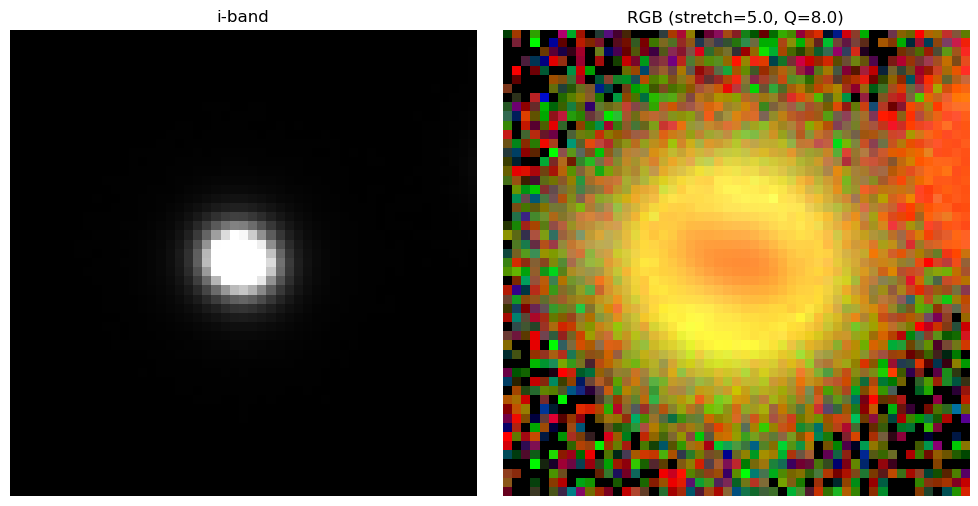

In [6]:
row = df.iloc[0]
print(f"objectId {row['objectId']}  ra={row['RA']:.6f}  dec={row['DEC']:.6f}  r={row['r_cModelMag']:.2f}")

ref = find_coadd_ref(row["RA"], row["DEC"], "i")
print(f"dataId: {dict(ref.dataId.required)}")

test_cutout = get_cutout(row["RA"], row["DEC"], "i")
arr = test_cutout.image.array
print(f"i-band stamp shape: {arr.shape}")
print(f"  flux percentiles (nJy): {np.nanpercentile(arr, [1, 50, 99]).round(2)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(arr, origin="lower", cmap="gray",
               vmin=np.nanpercentile(arr, 1), vmax=np.nanpercentile(arr, 99))
axes[0].set_title("i-band")
axes[1].imshow(get_rgb_cutout(row["RA"], row["DEC"]), origin="lower")
axes[1].set_title(f"RGB (stretch={LUPTON_STRETCH}, Q={LUPTON_Q})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Generate the mosaics

Each stamp is labelled with the r magnitude, r-band `psf - cModel` (near 0 means
point-like despite the extendedness flag), and a blend marker:
**B** = `detect_fromBlend`, **I** = `detect_isIsolated`.

This is 3 patch queries + 3 WCS reads + 3 pixel reads per object, so expect the
full 443-object run to take a while. Set `N_OBJECTS` for a quick look first.

saved cutout_mosaics/mosaic_001.png


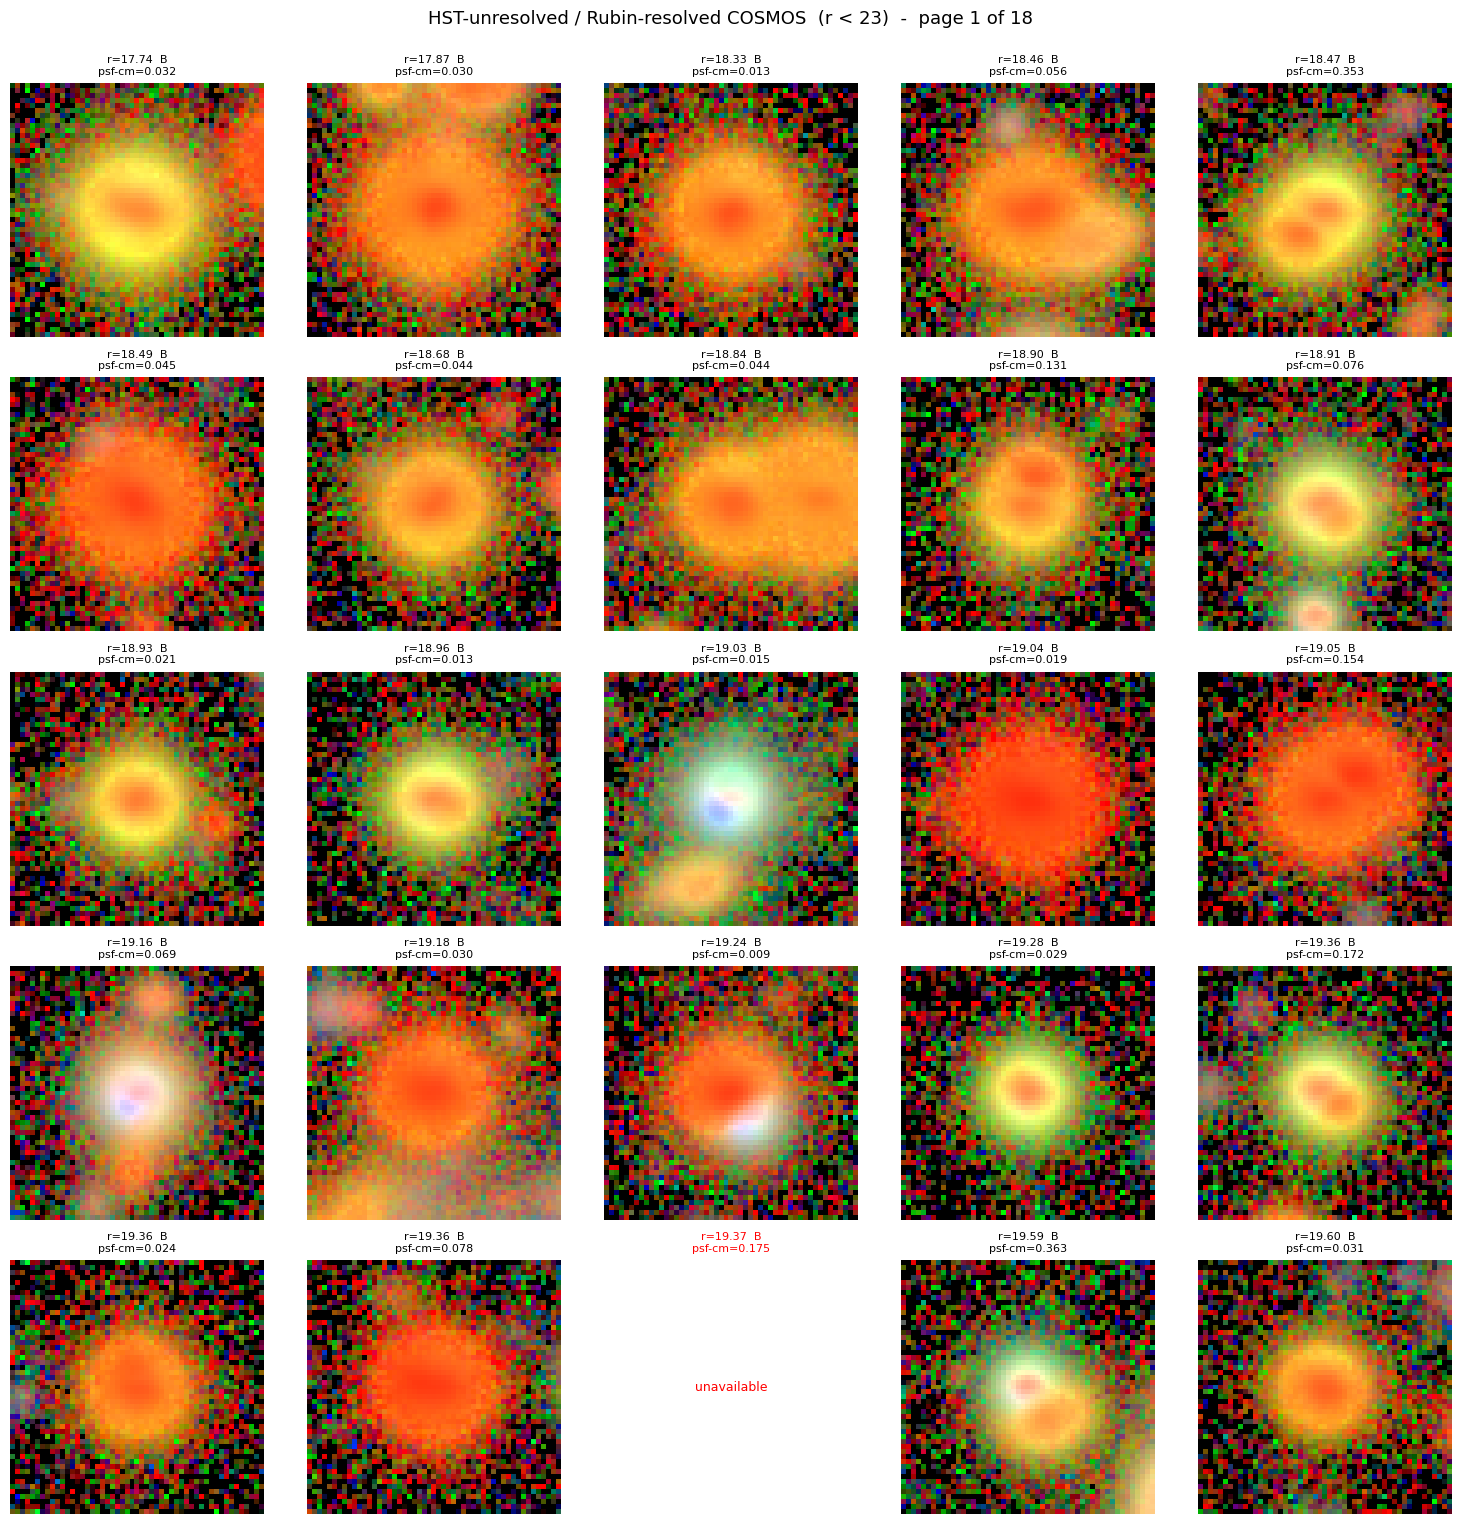

saved cutout_mosaics/mosaic_002.png


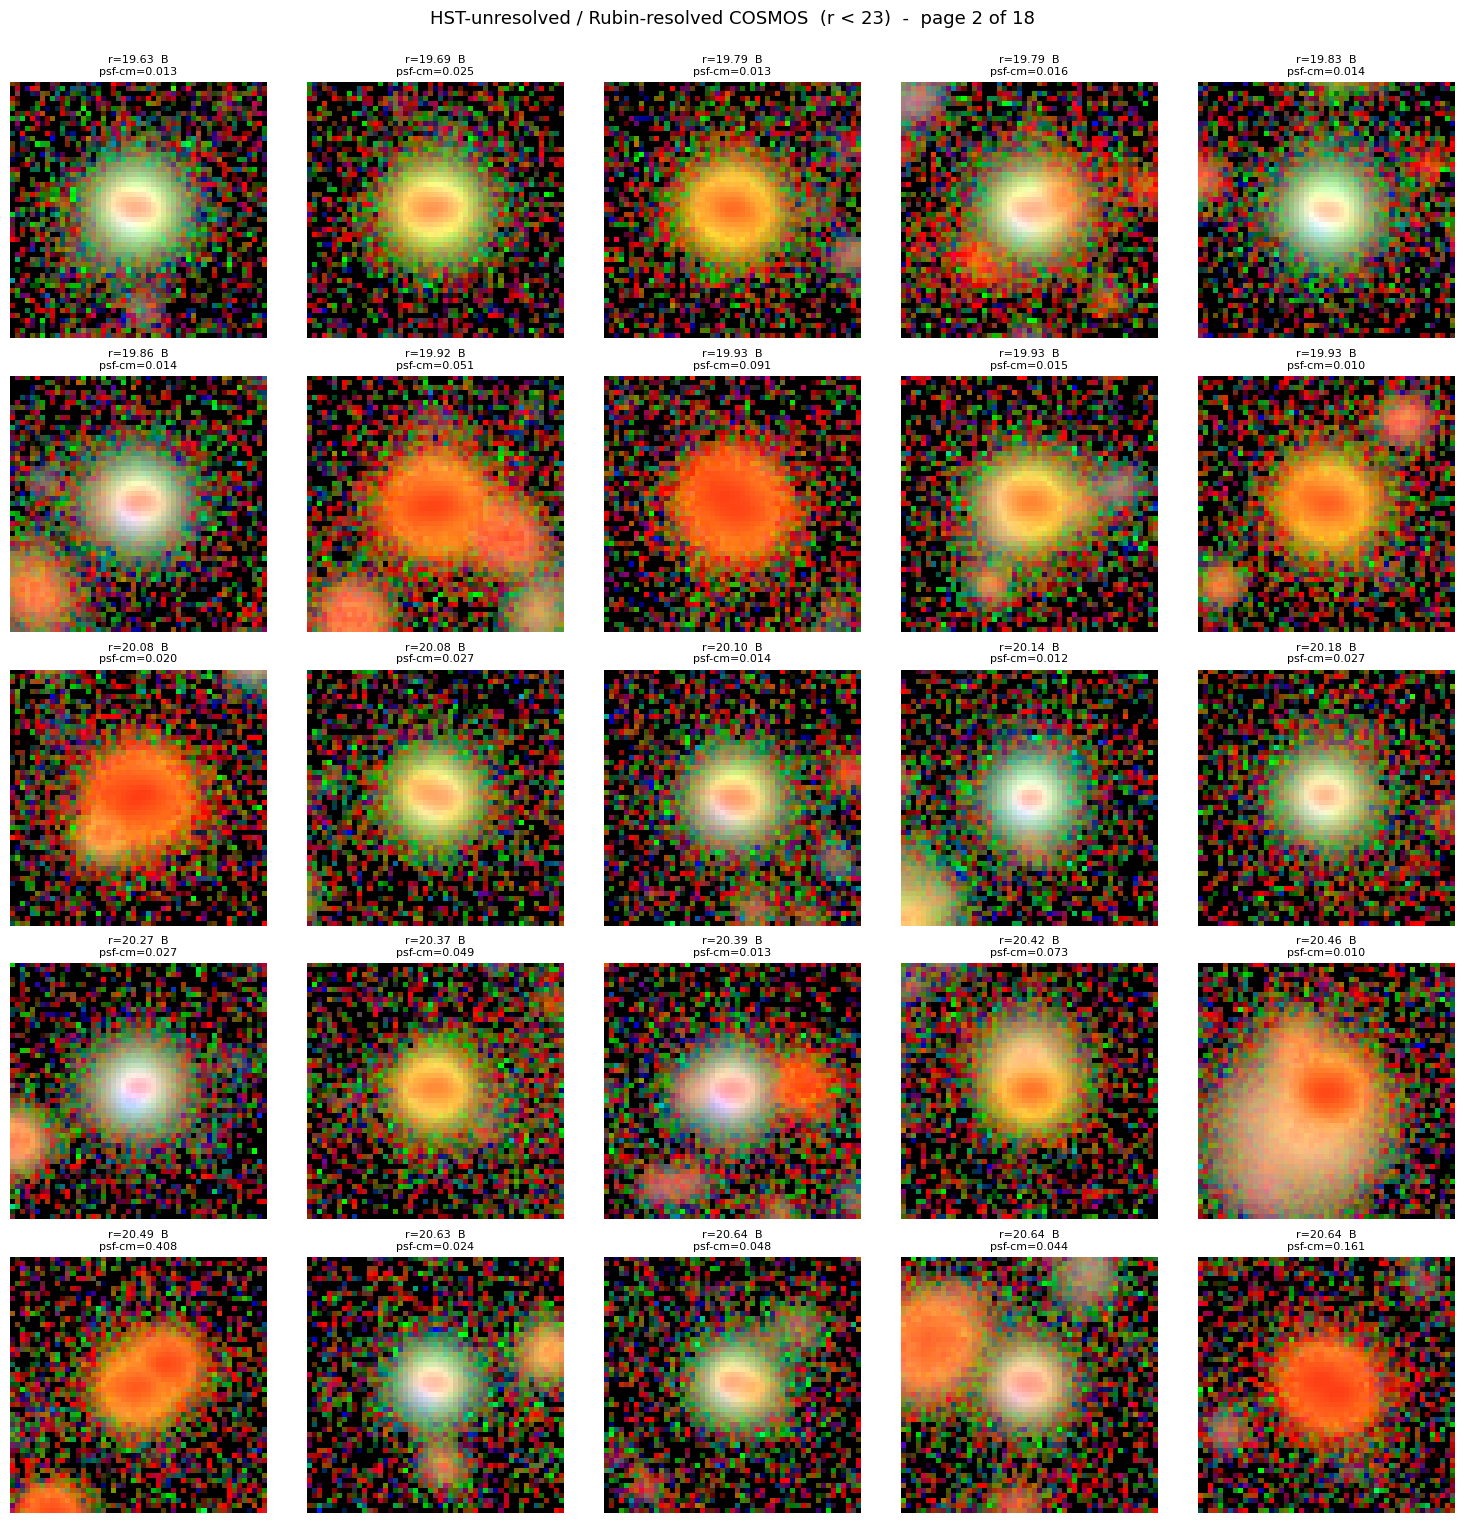

saved cutout_mosaics/mosaic_003.png


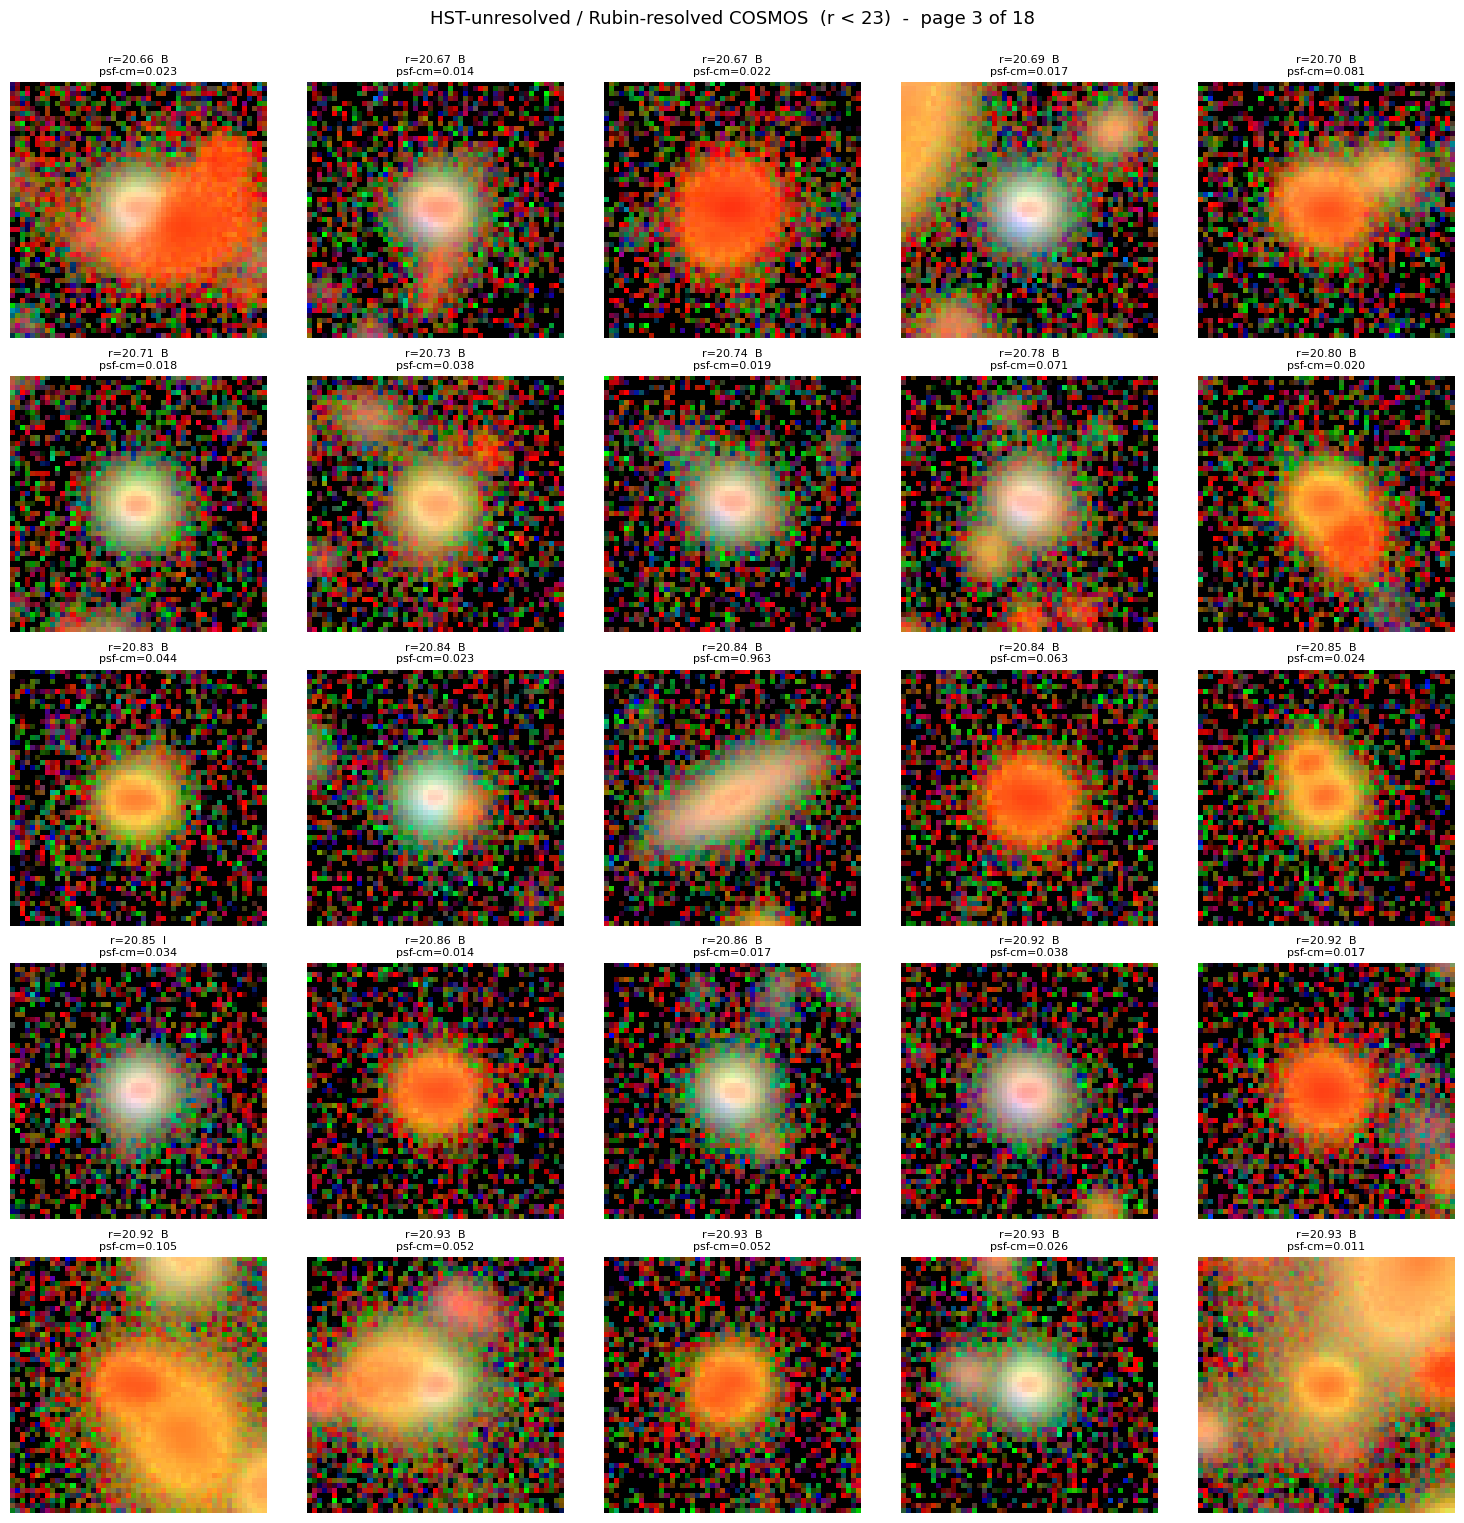

saved cutout_mosaics/mosaic_004.png


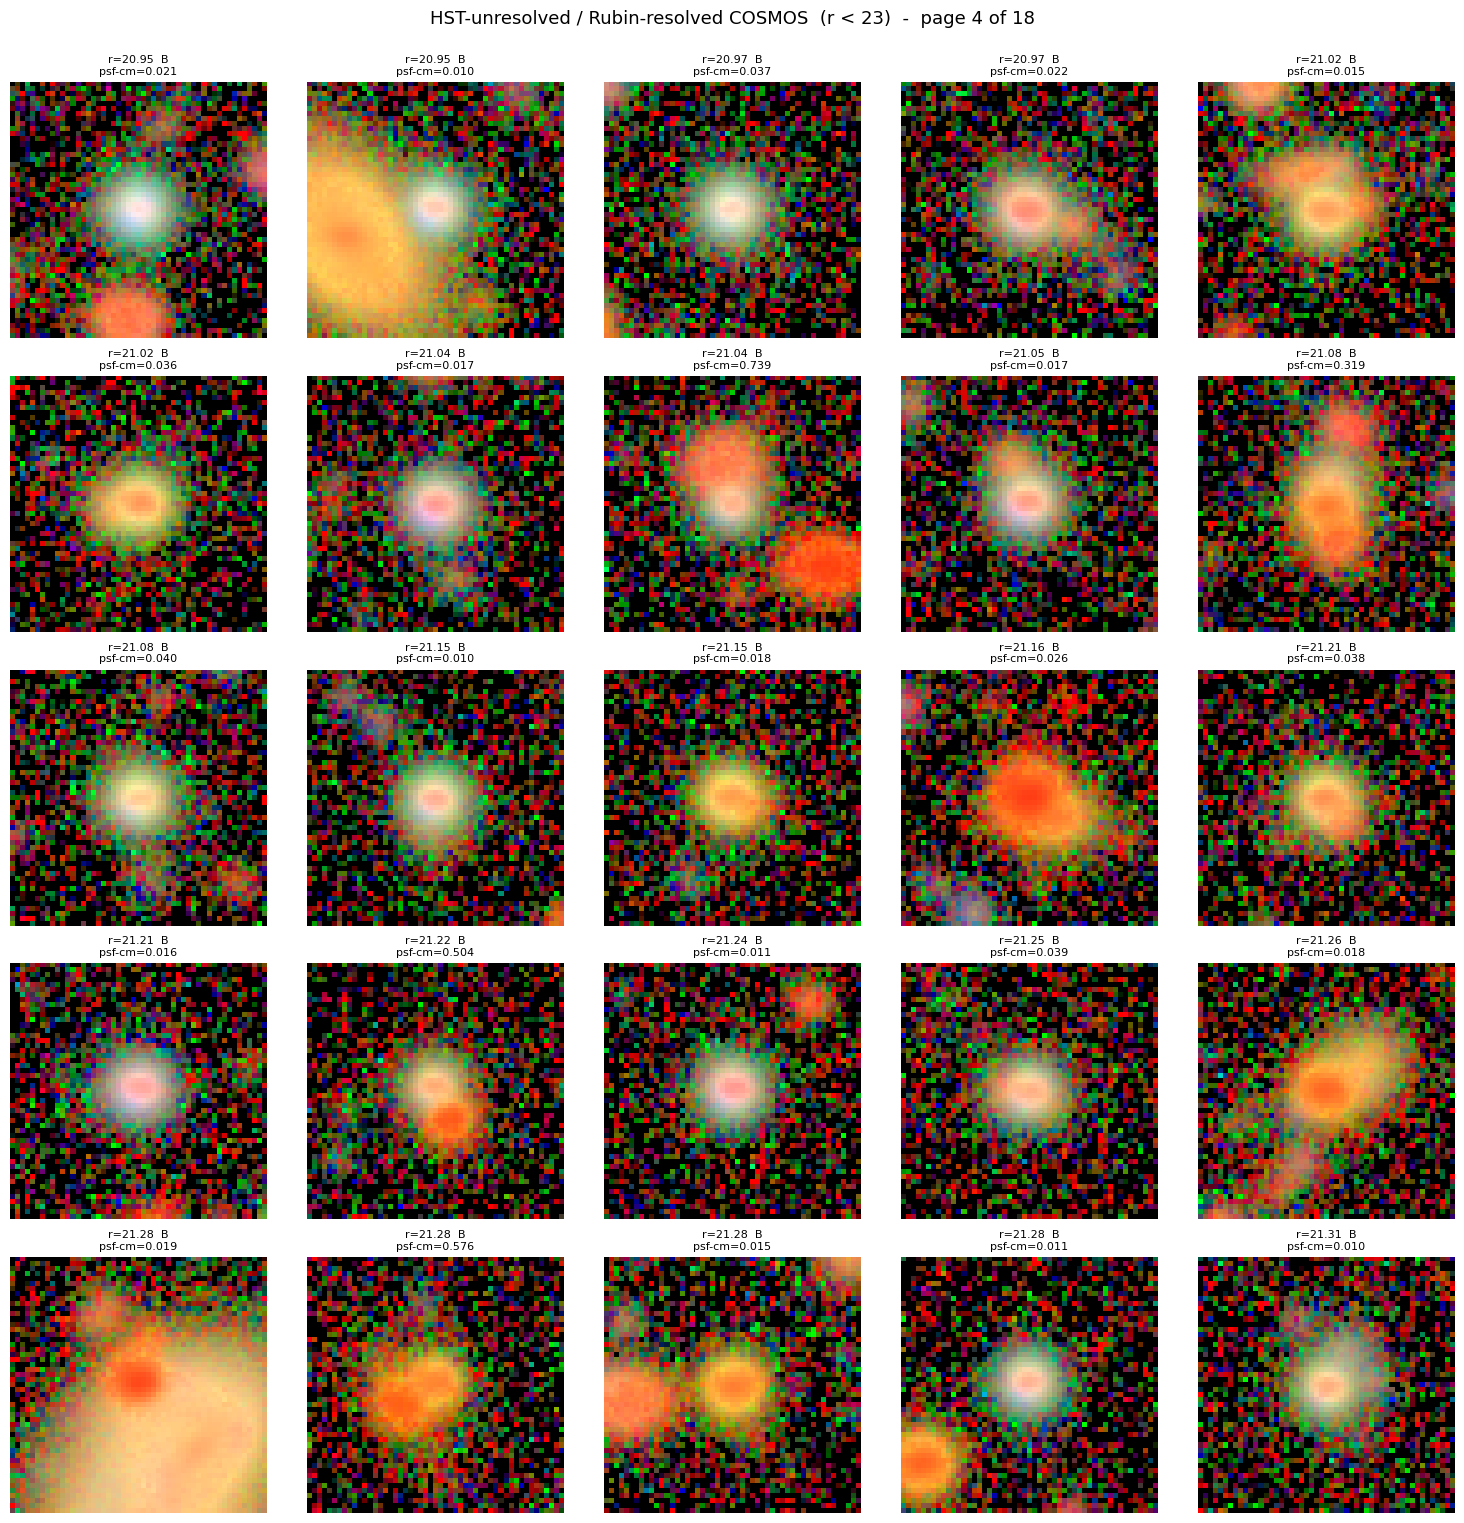

saved cutout_mosaics/mosaic_005.png


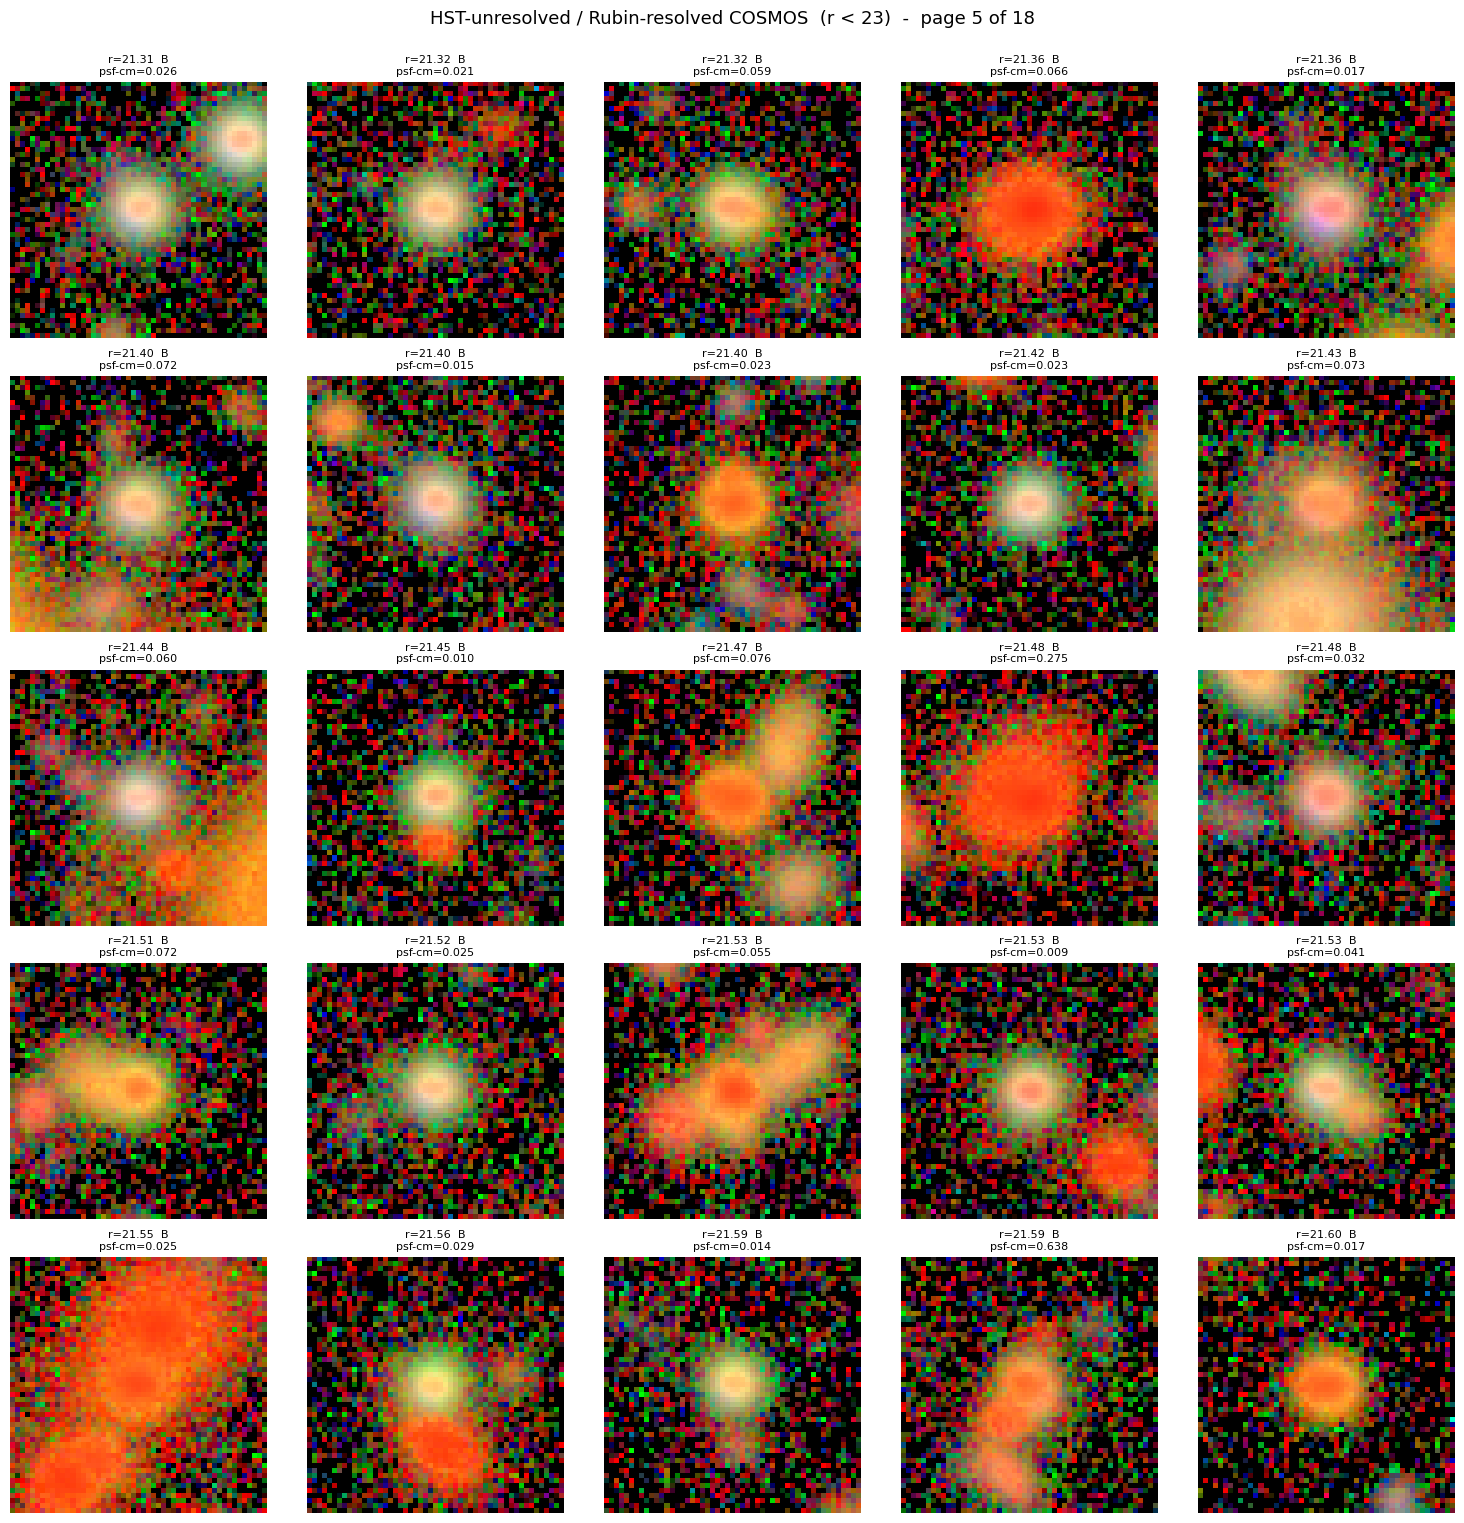

saved cutout_mosaics/mosaic_006.png


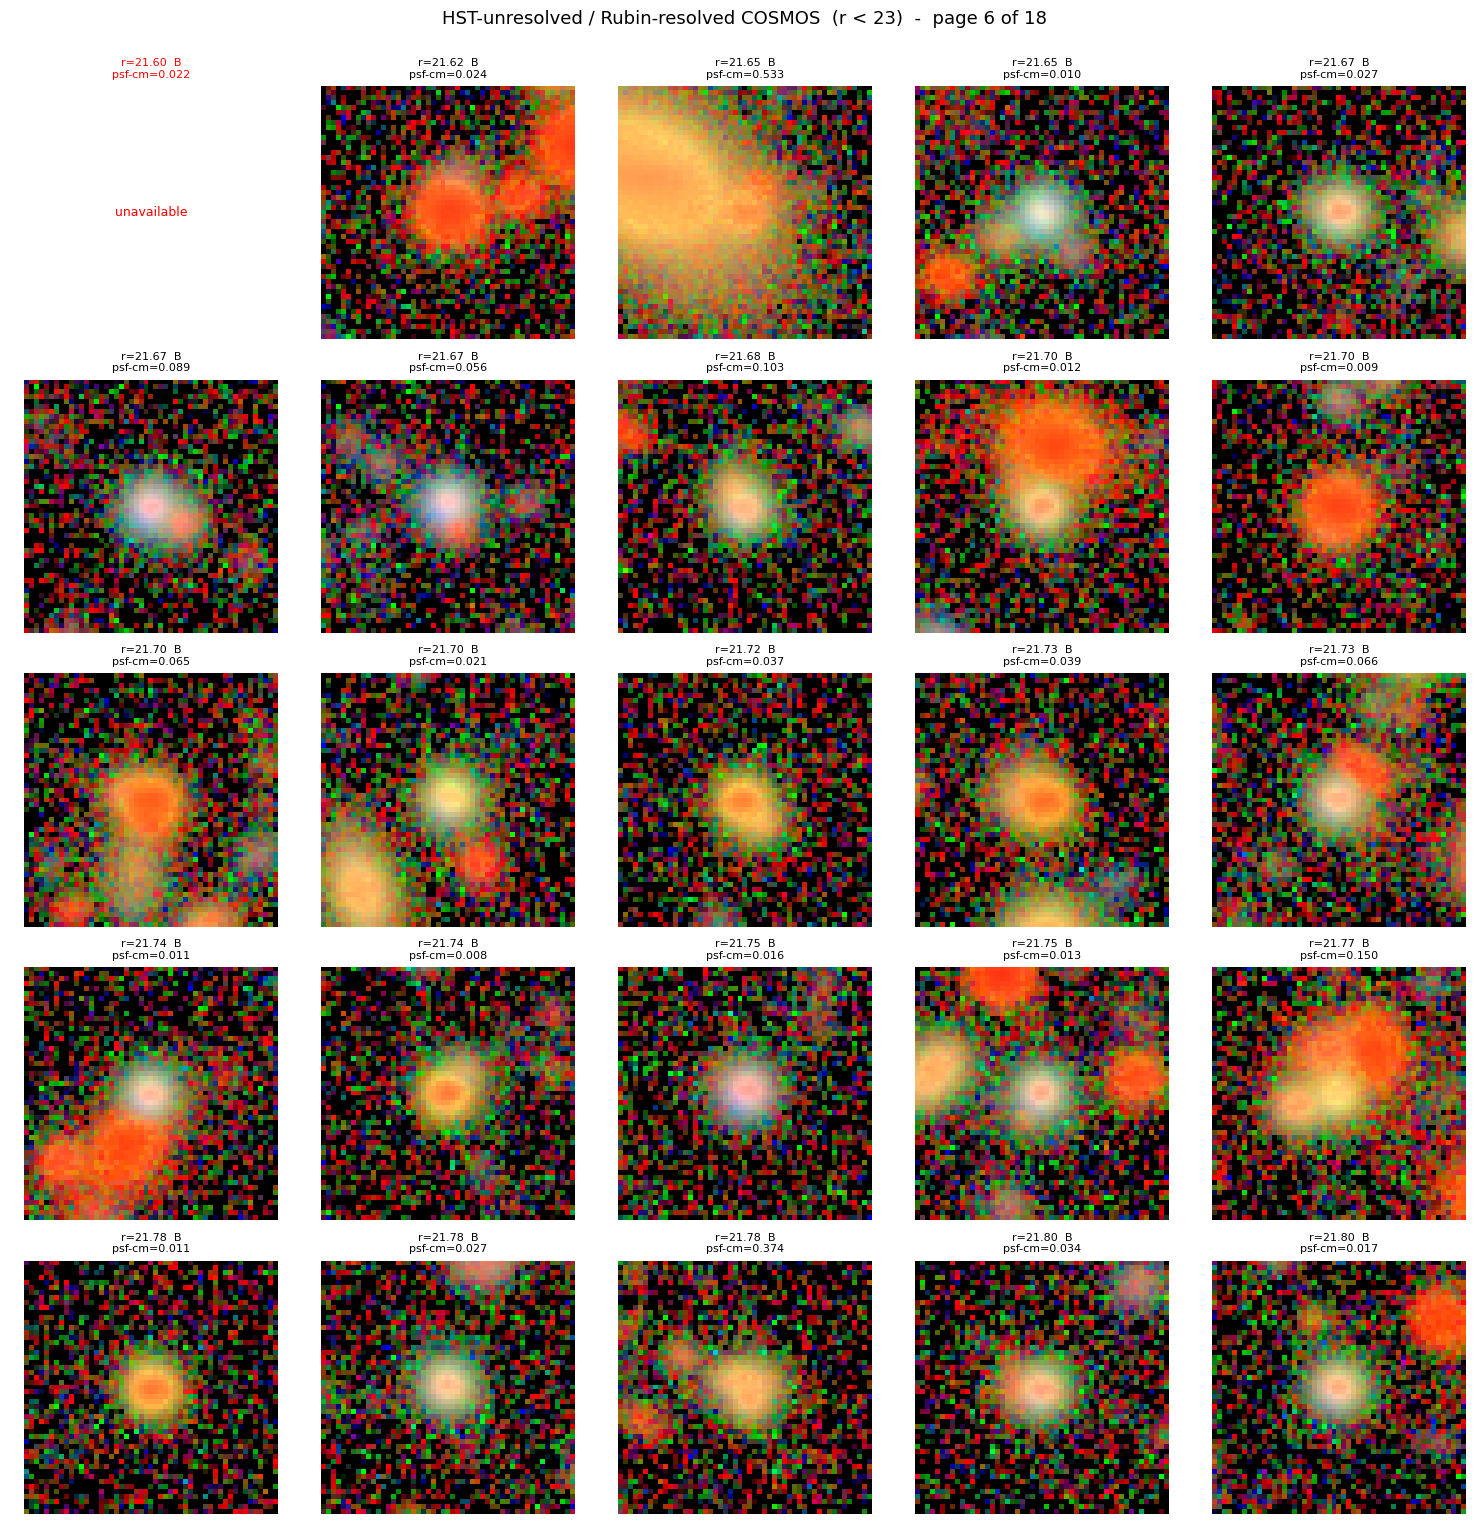

saved cutout_mosaics/mosaic_007.png


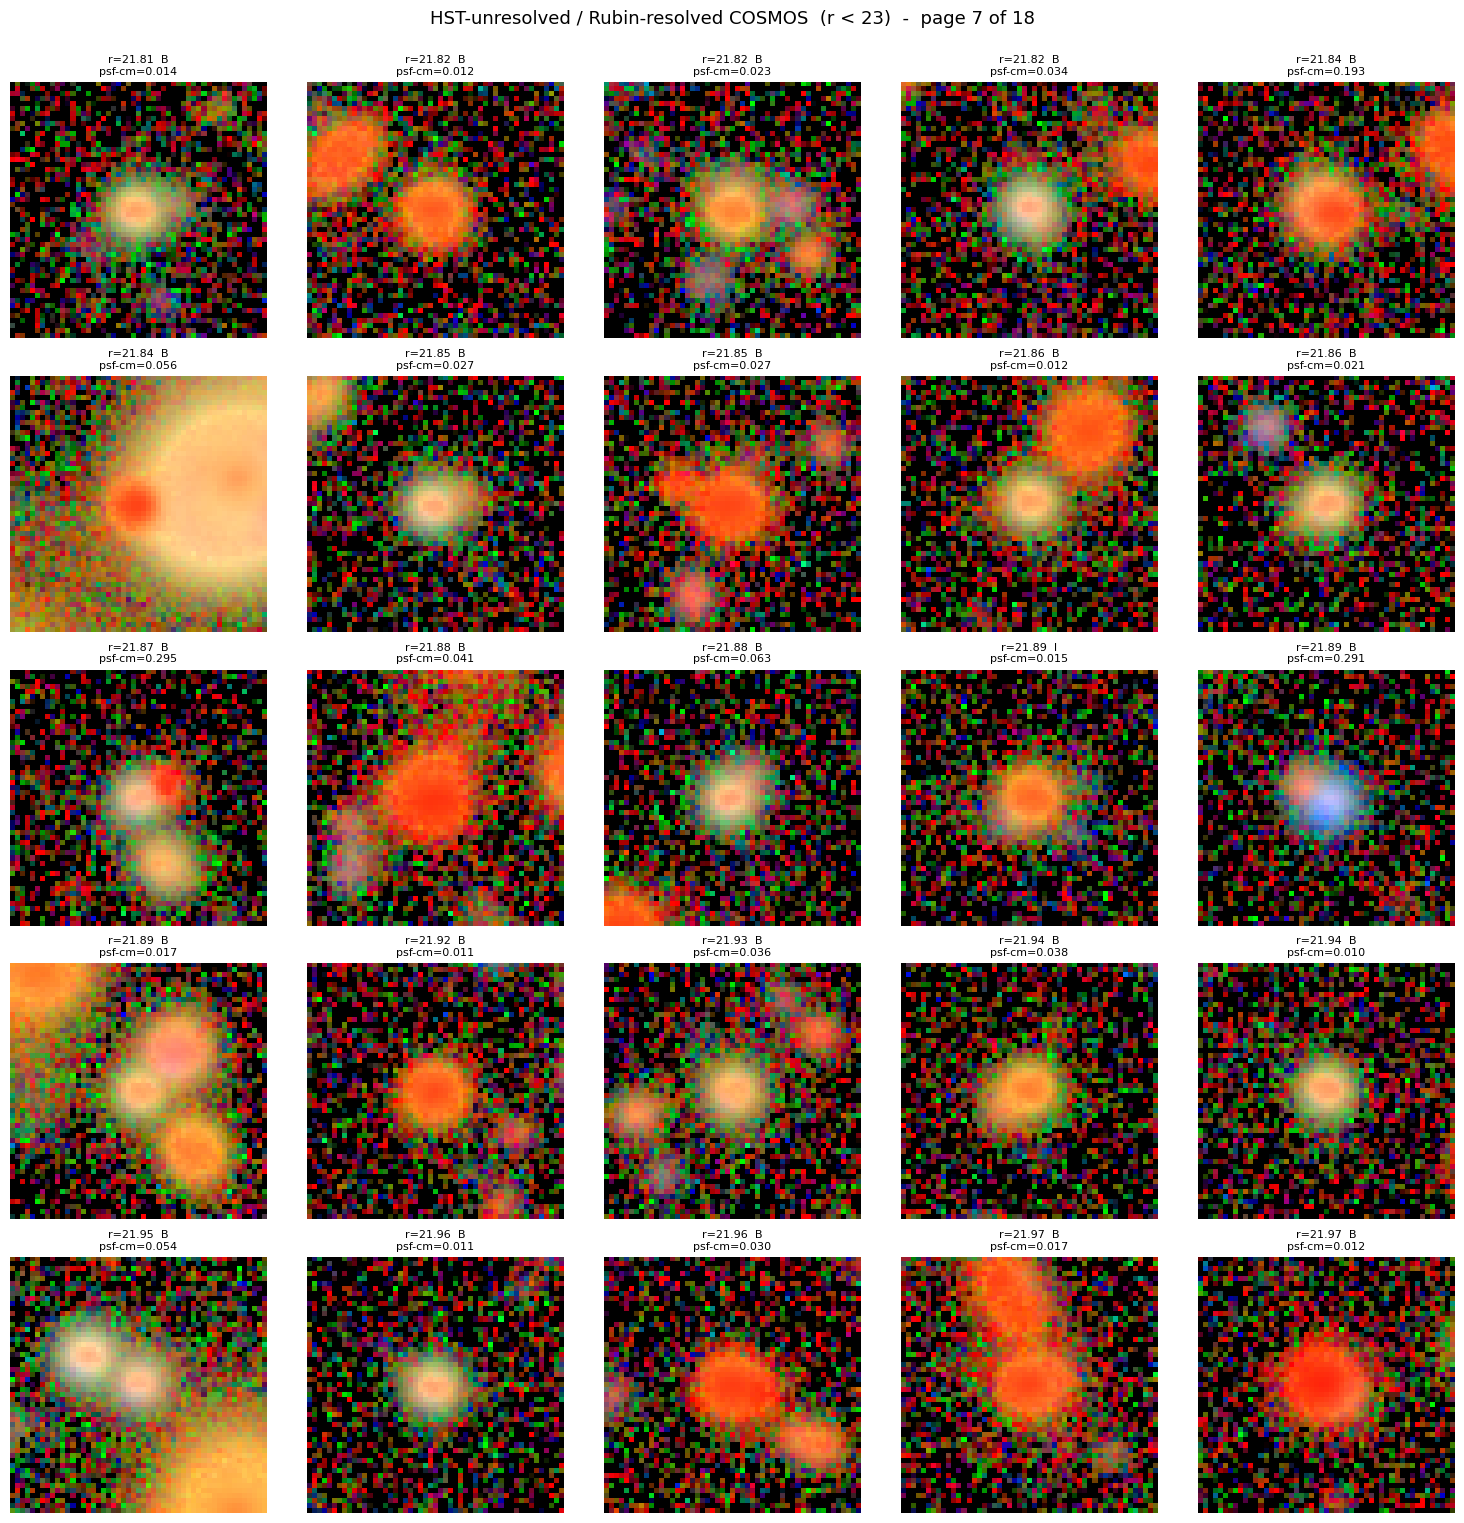

saved cutout_mosaics/mosaic_008.png


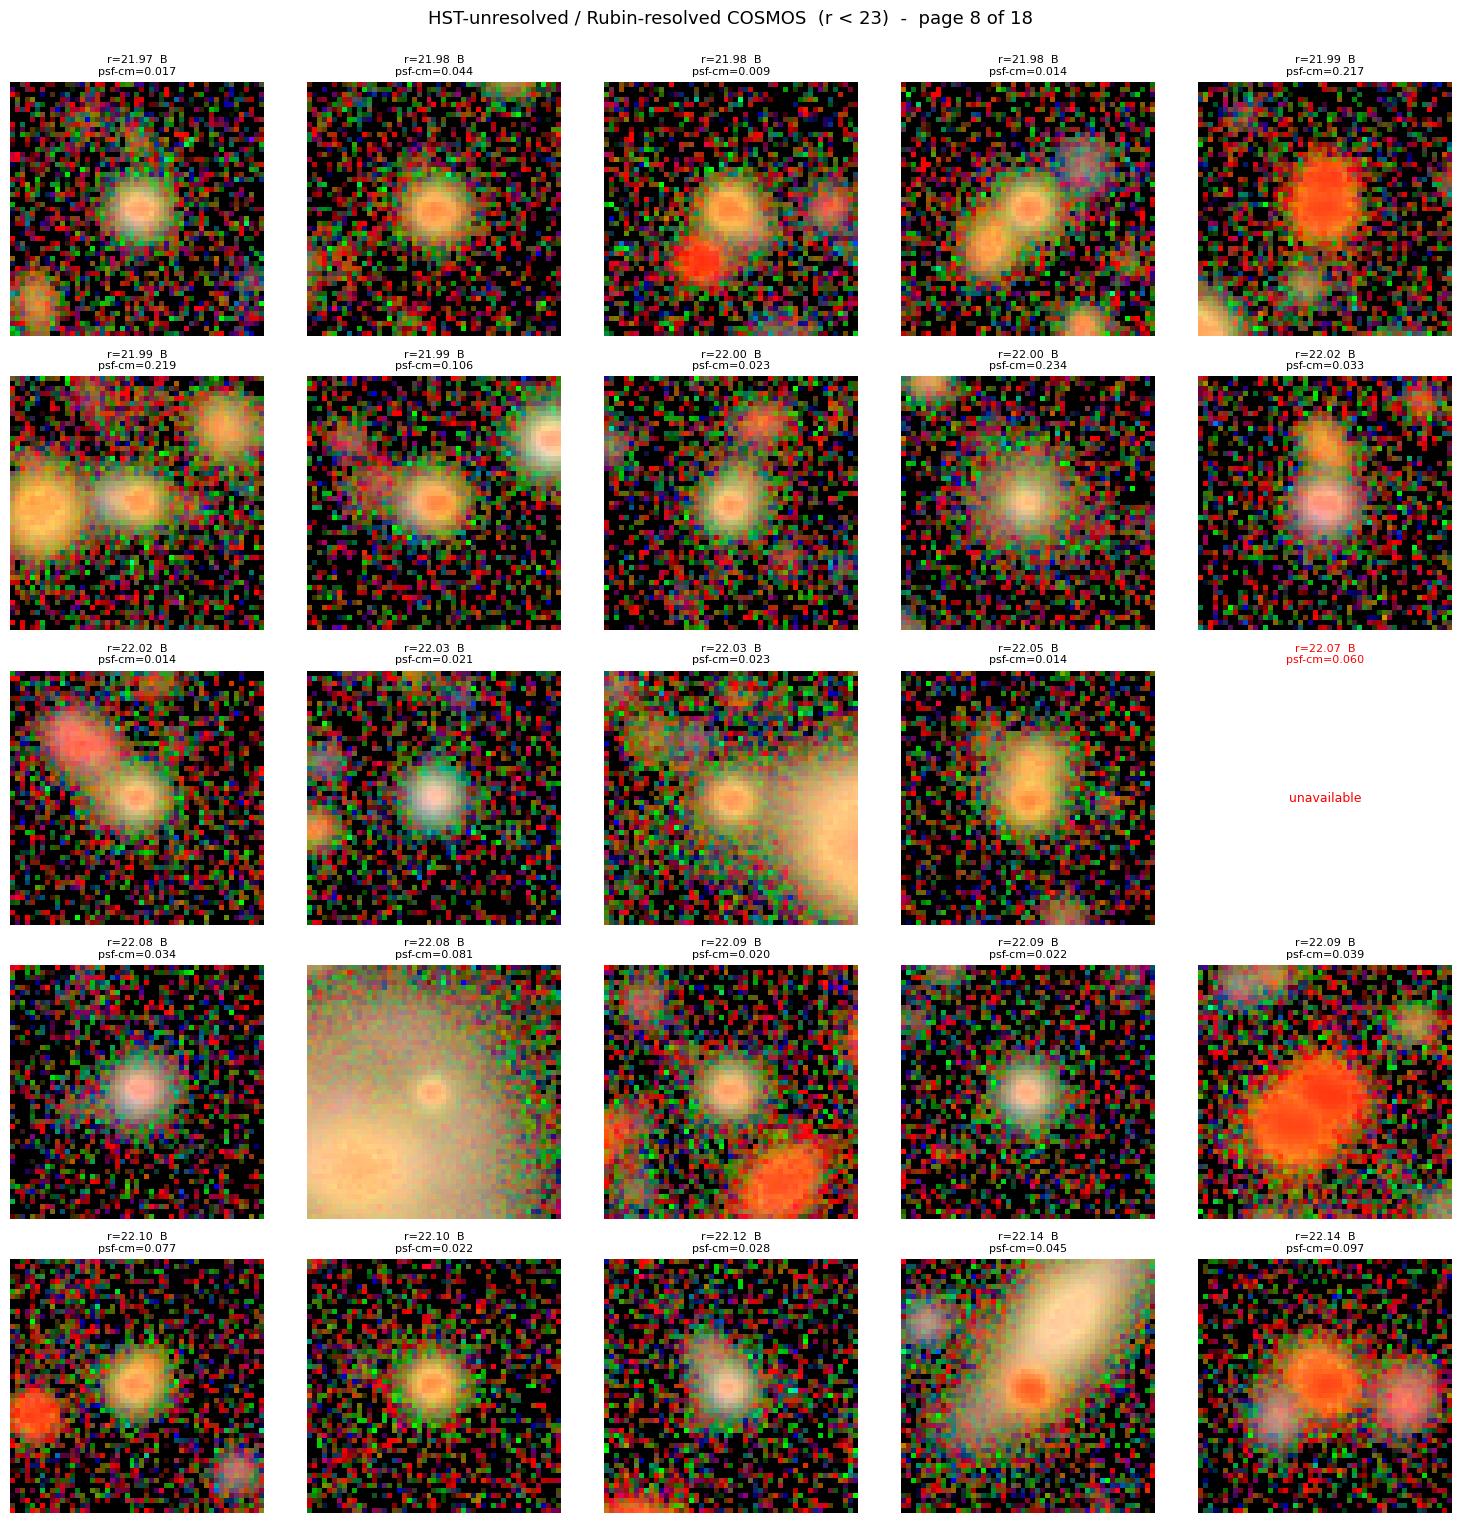

saved cutout_mosaics/mosaic_009.png


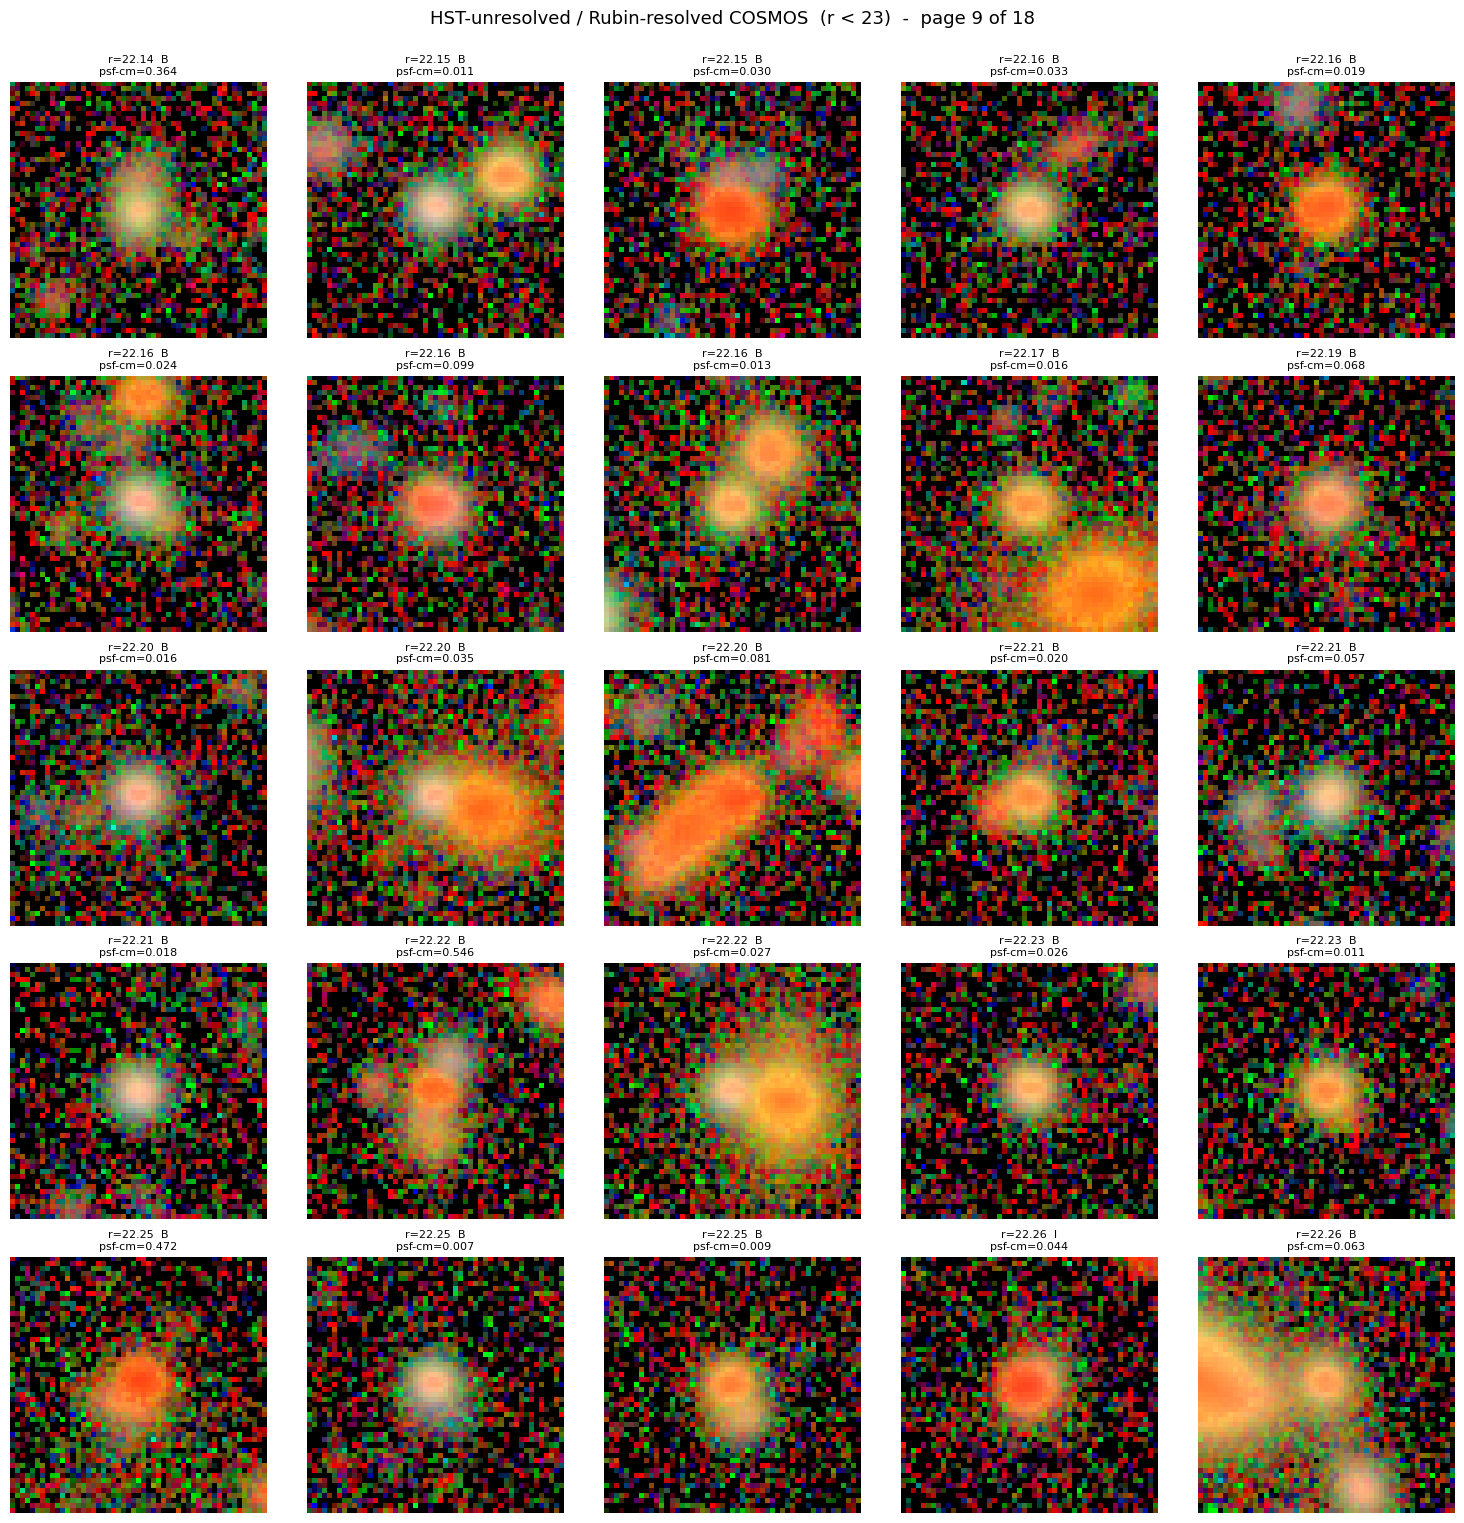

saved cutout_mosaics/mosaic_010.png


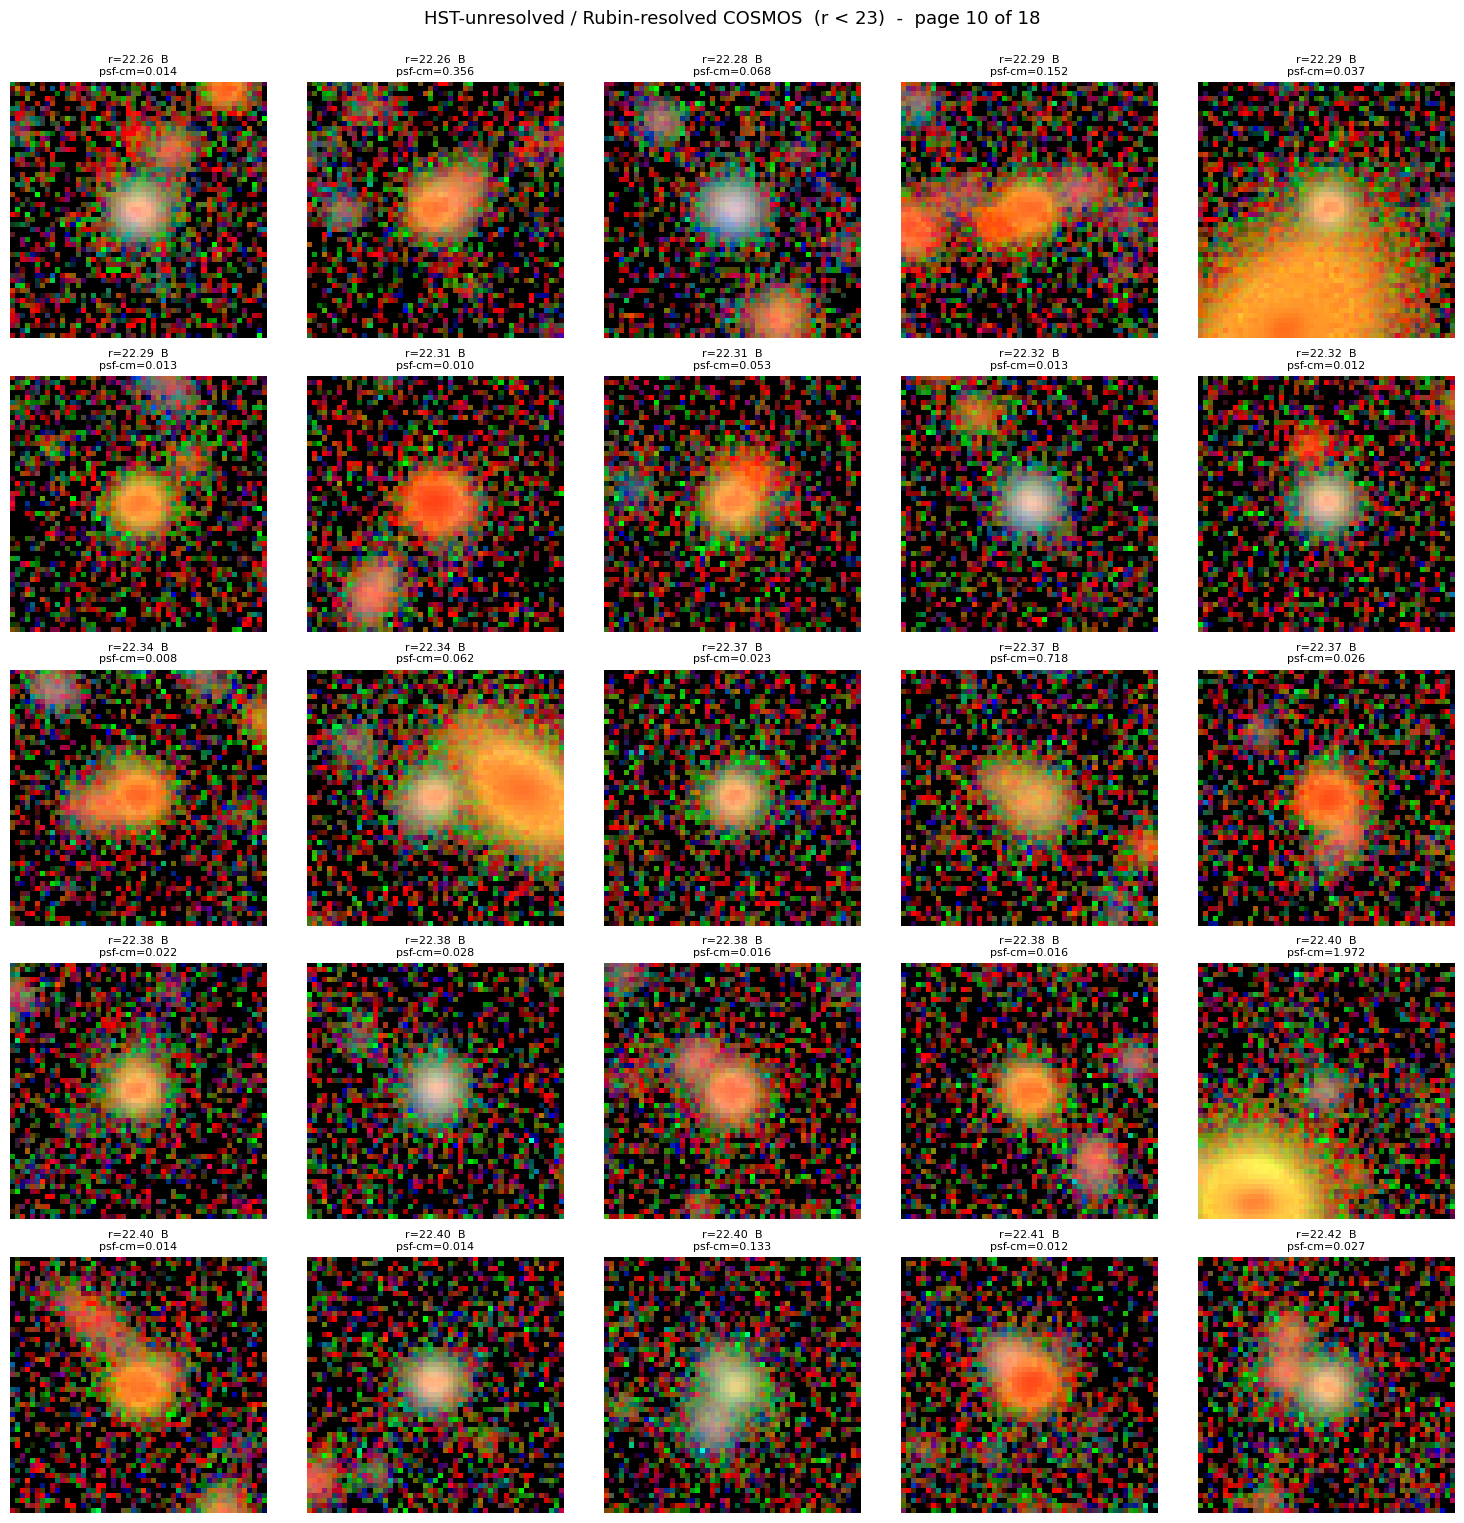

saved cutout_mosaics/mosaic_011.png


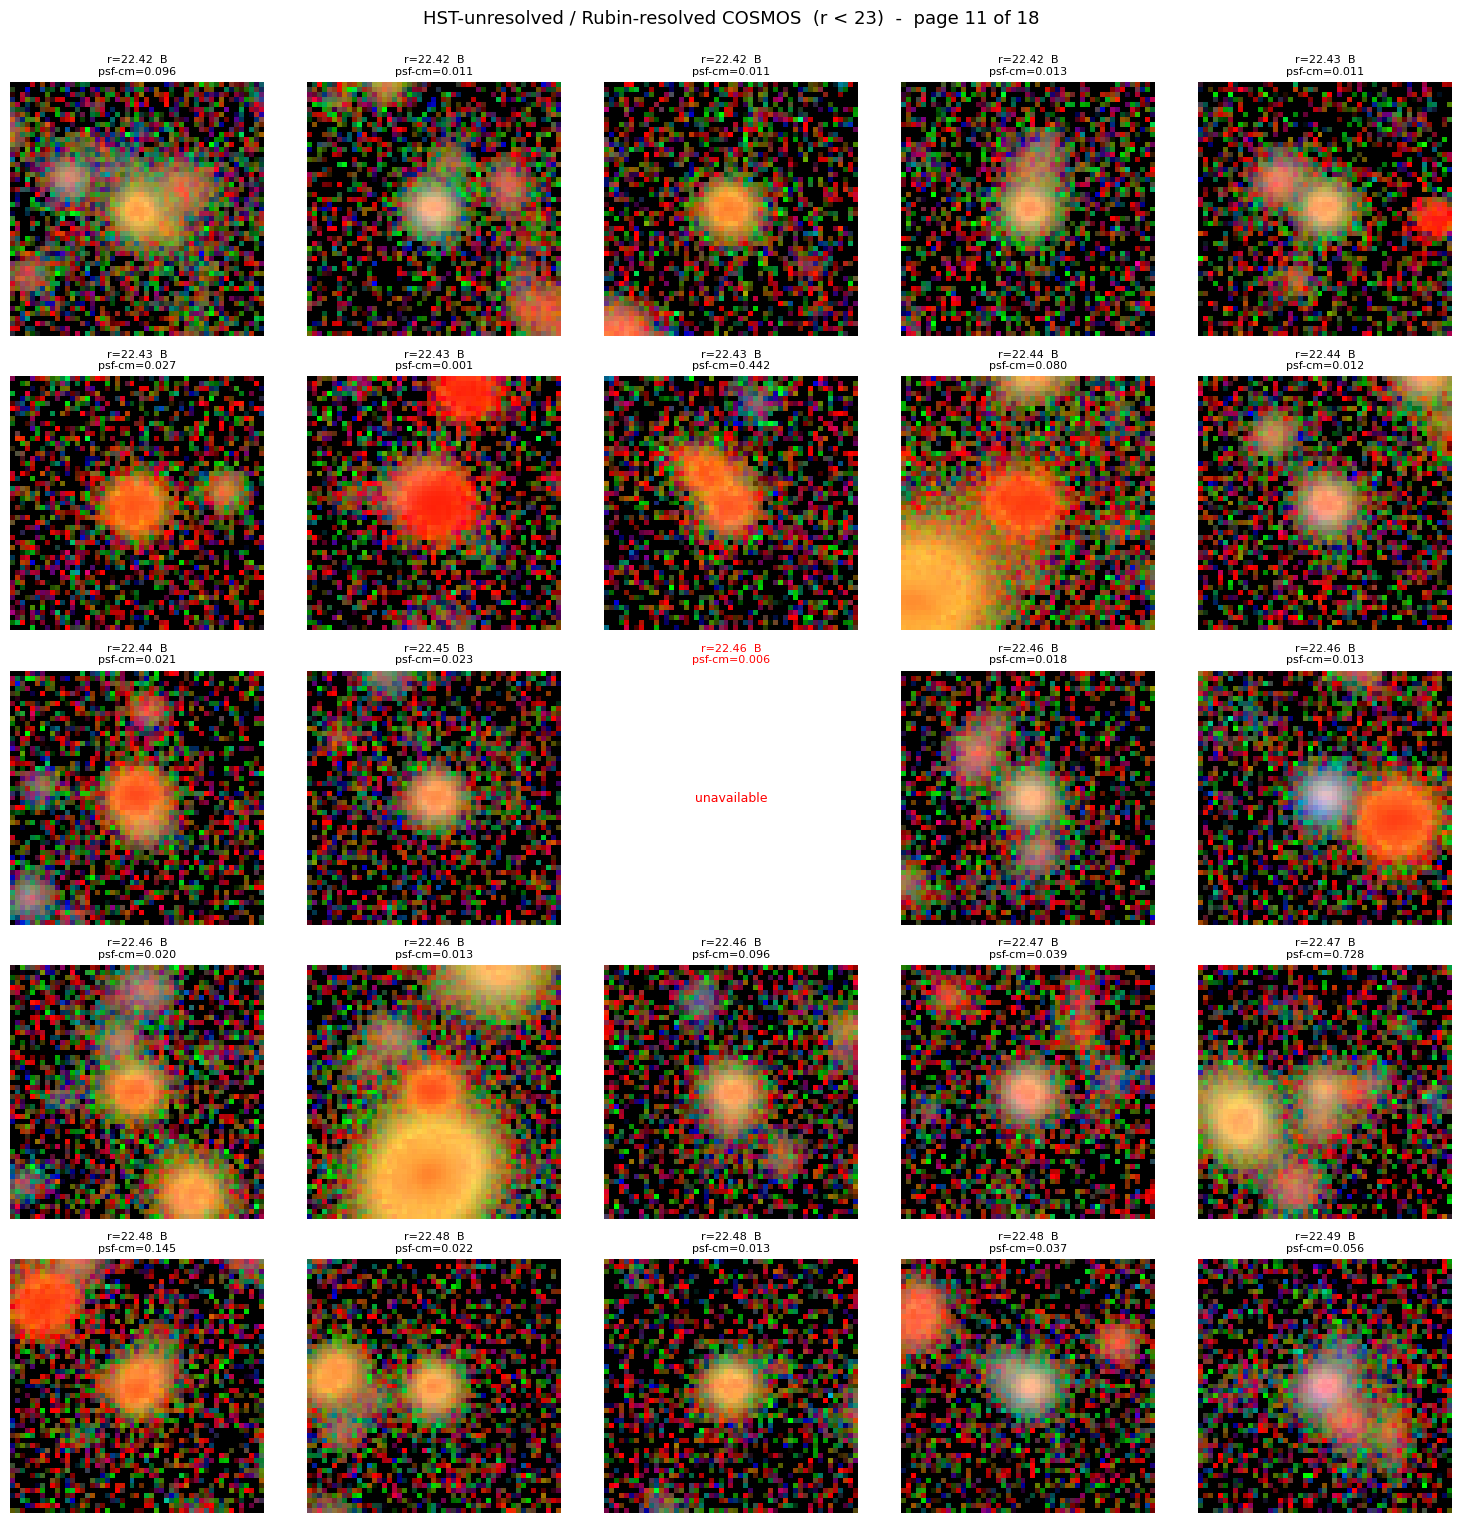

saved cutout_mosaics/mosaic_012.png


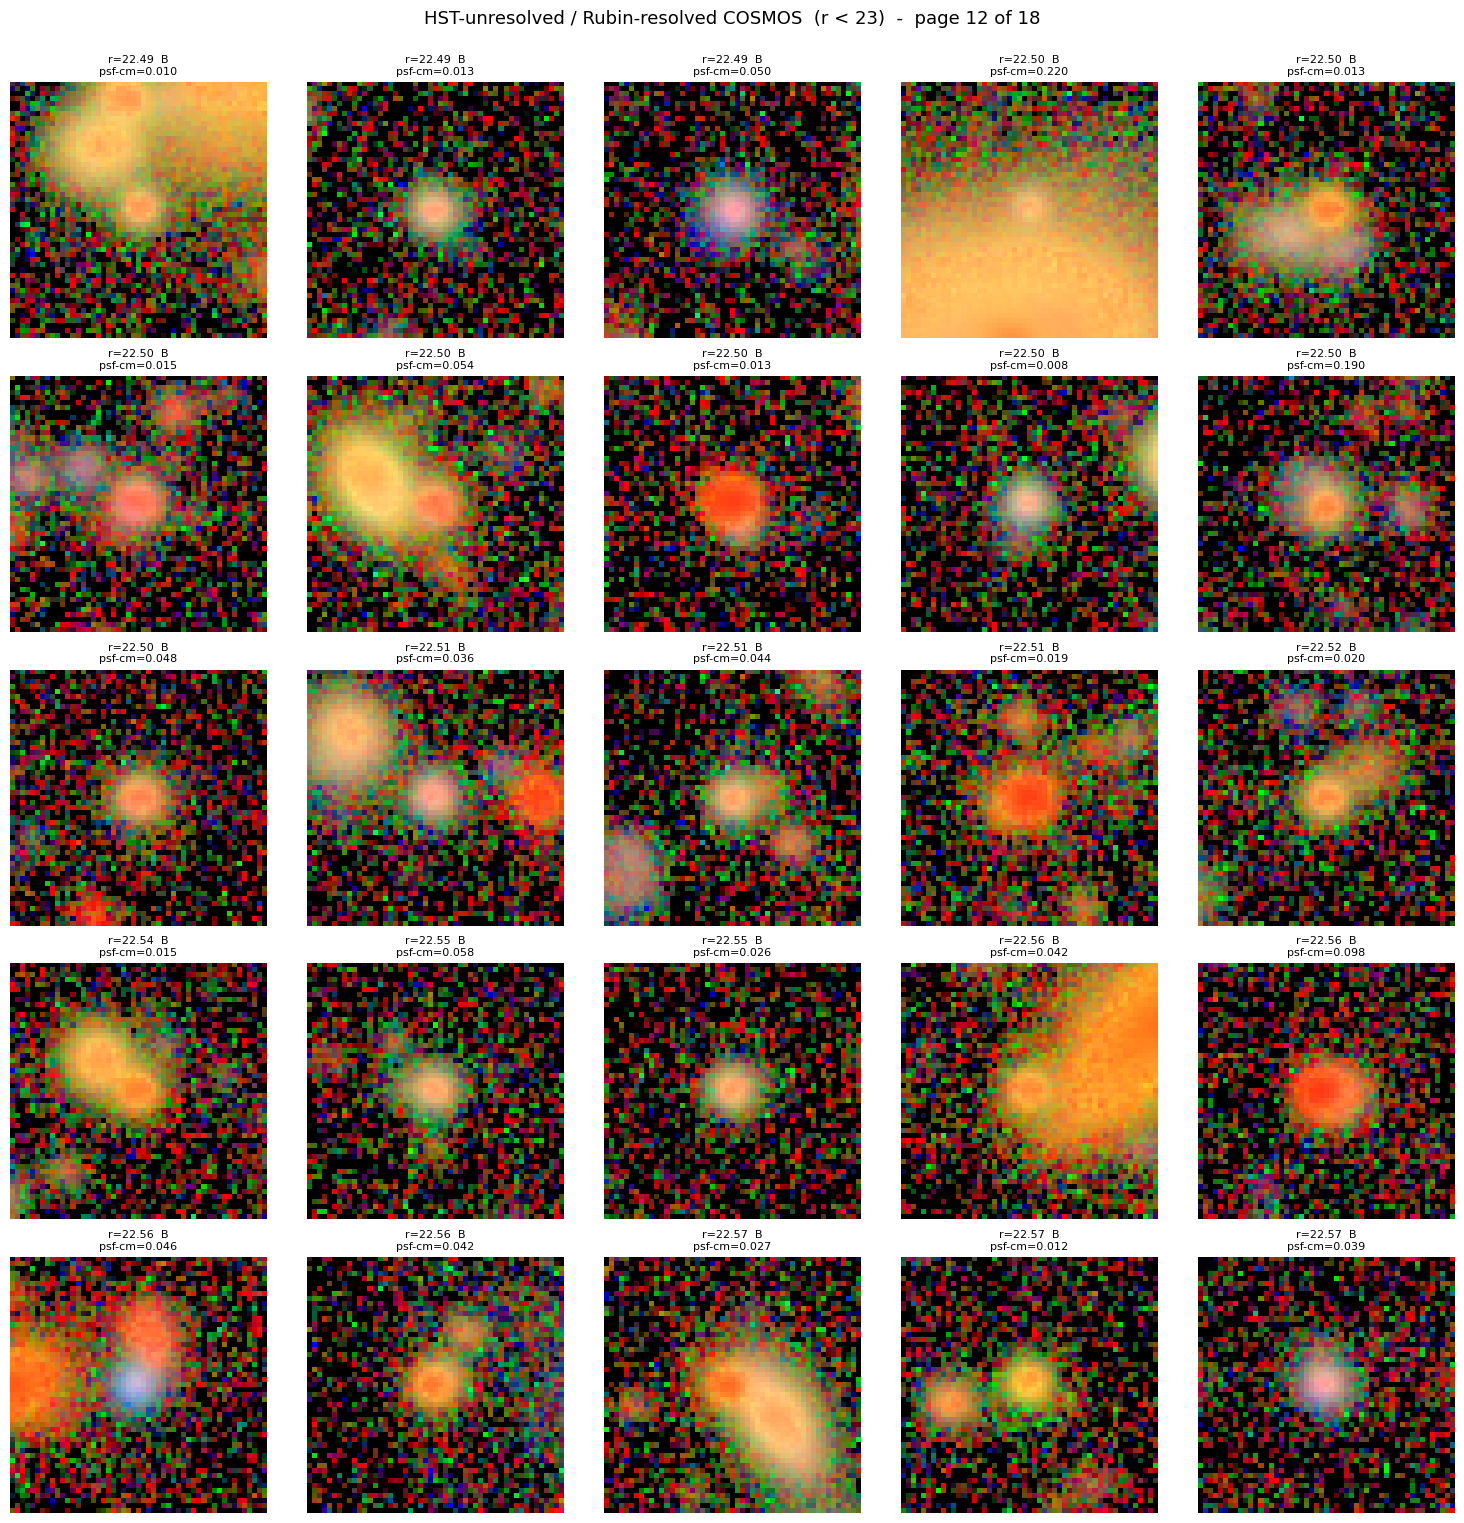

saved cutout_mosaics/mosaic_013.png


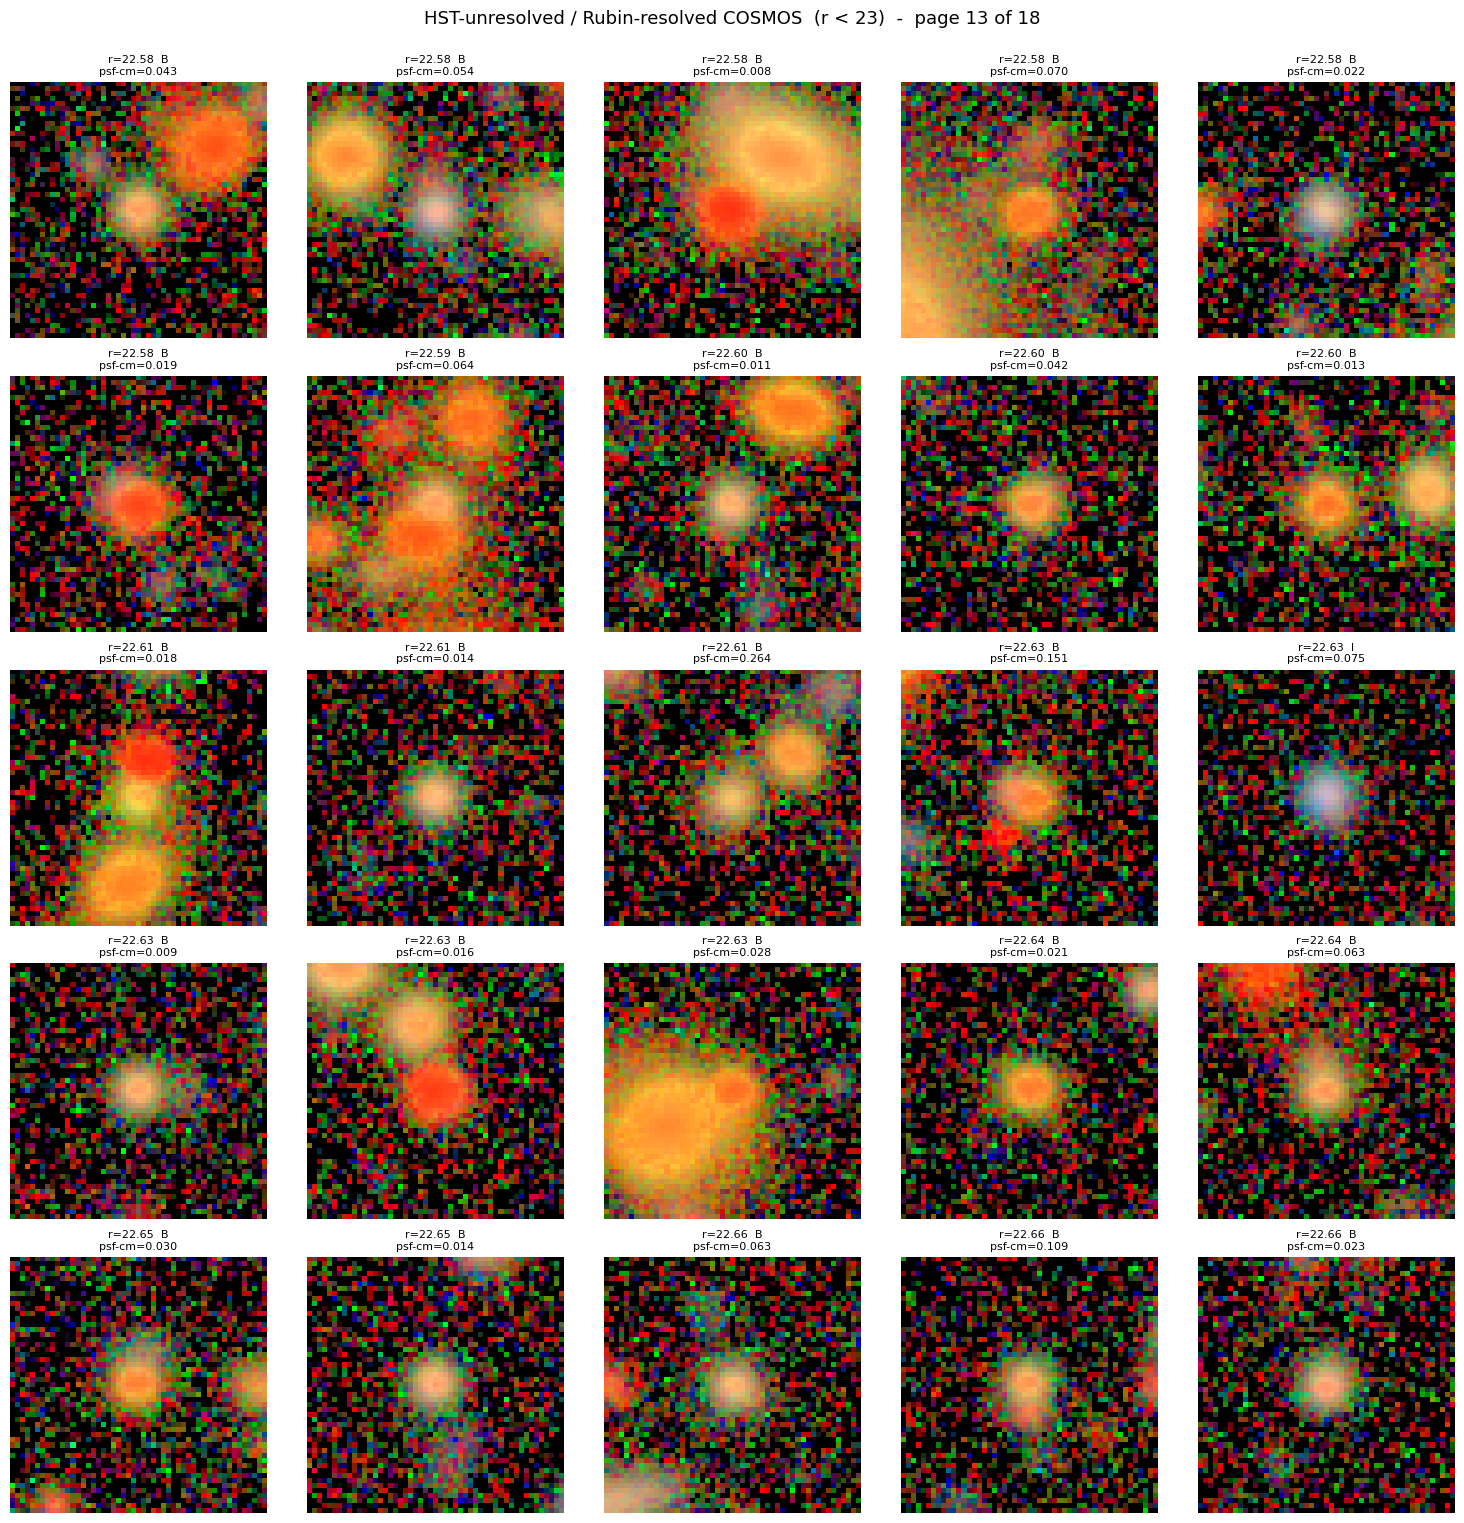

saved cutout_mosaics/mosaic_014.png


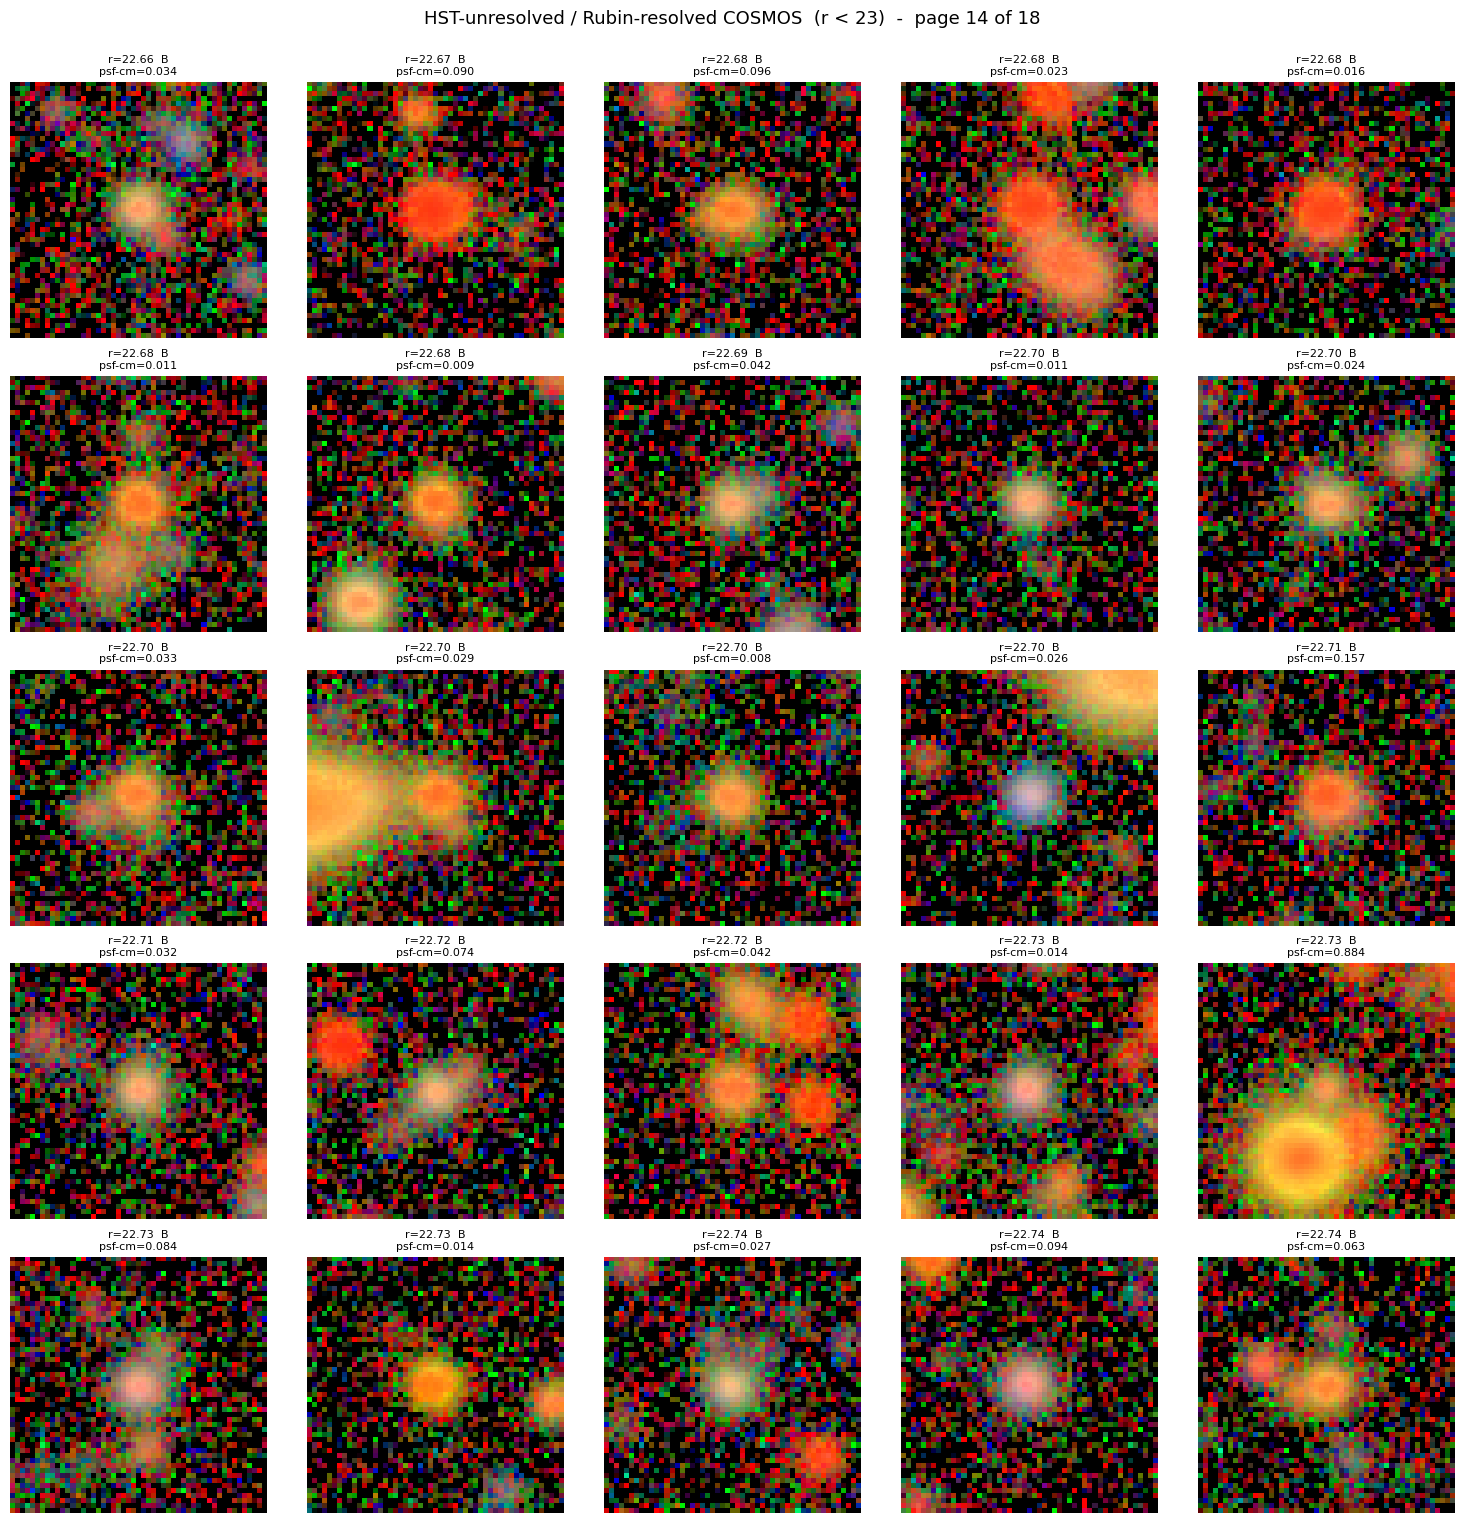

saved cutout_mosaics/mosaic_015.png


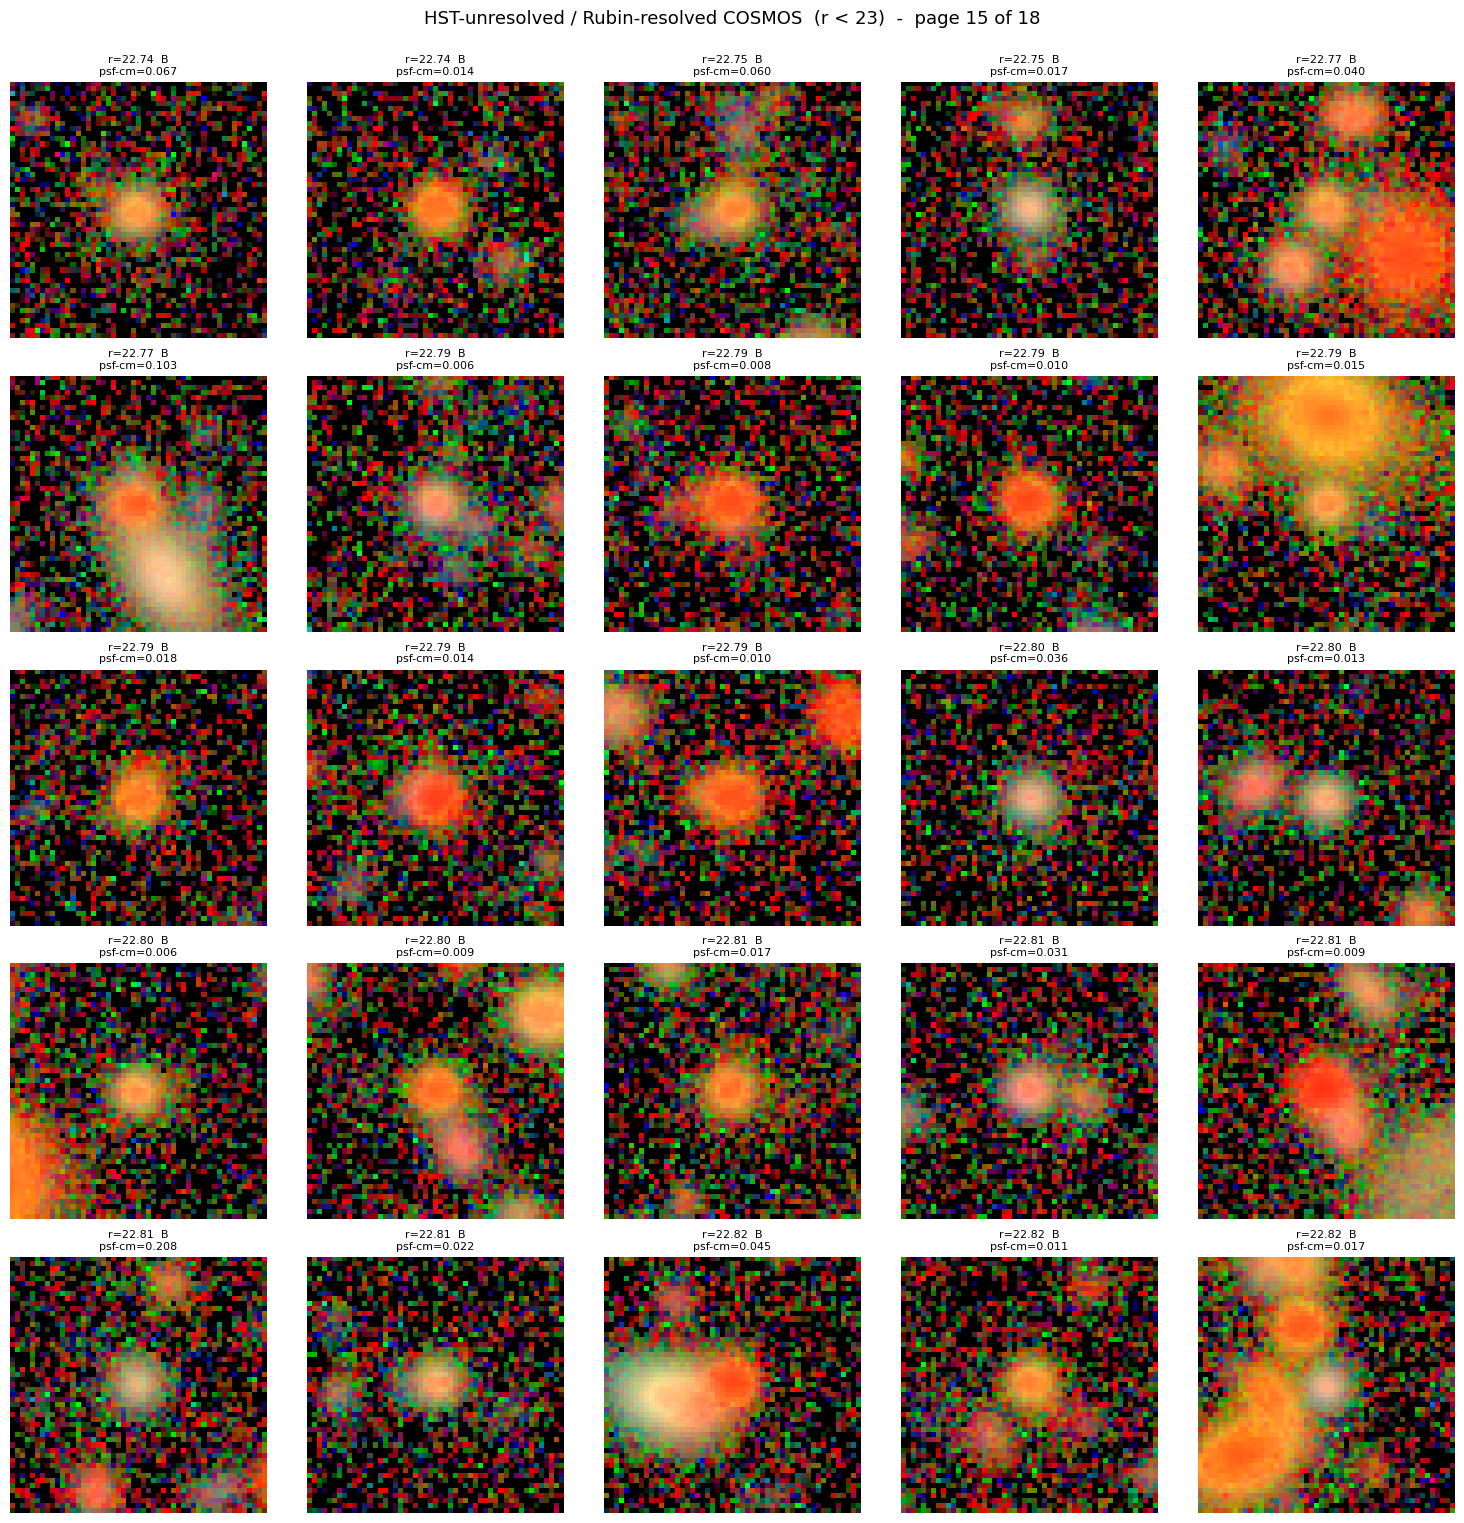

saved cutout_mosaics/mosaic_016.png


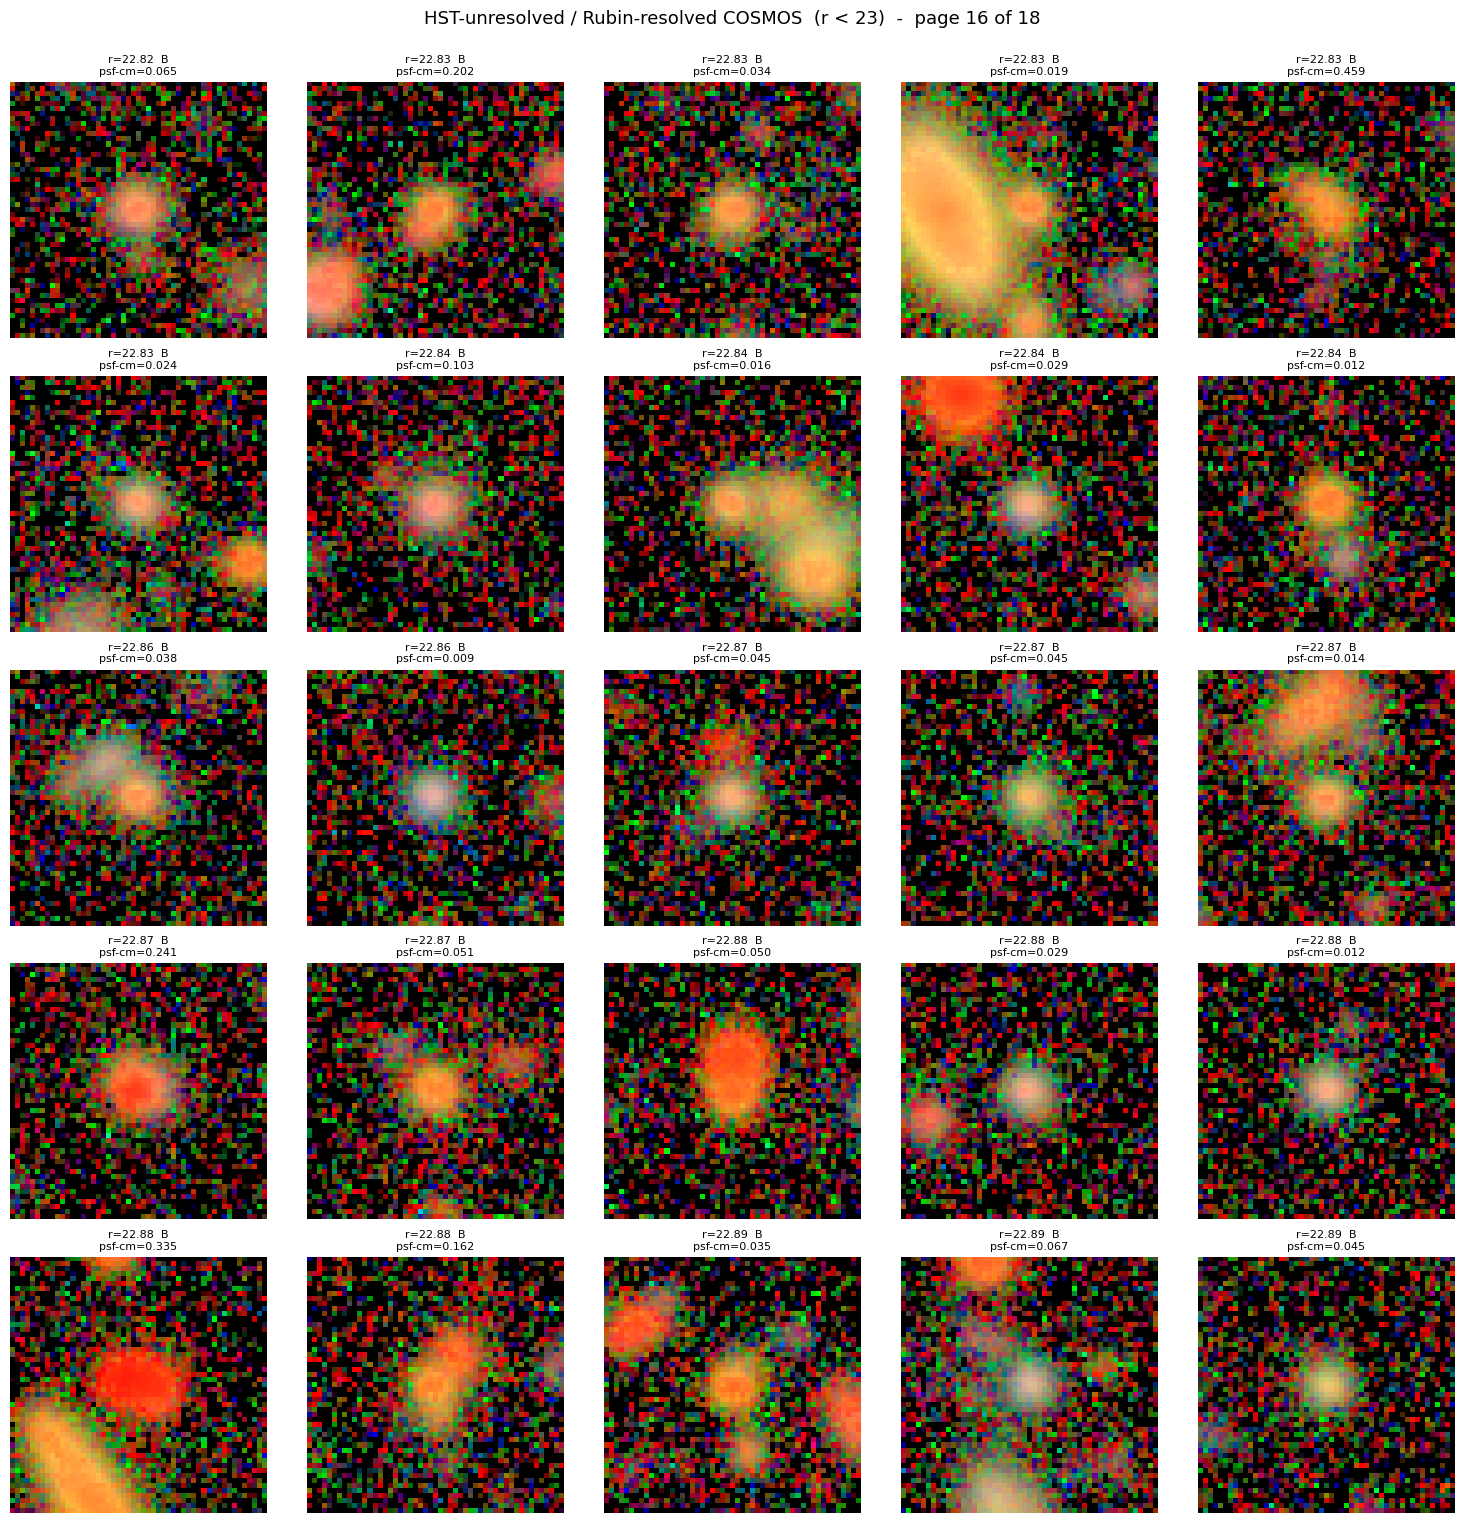

saved cutout_mosaics/mosaic_017.png


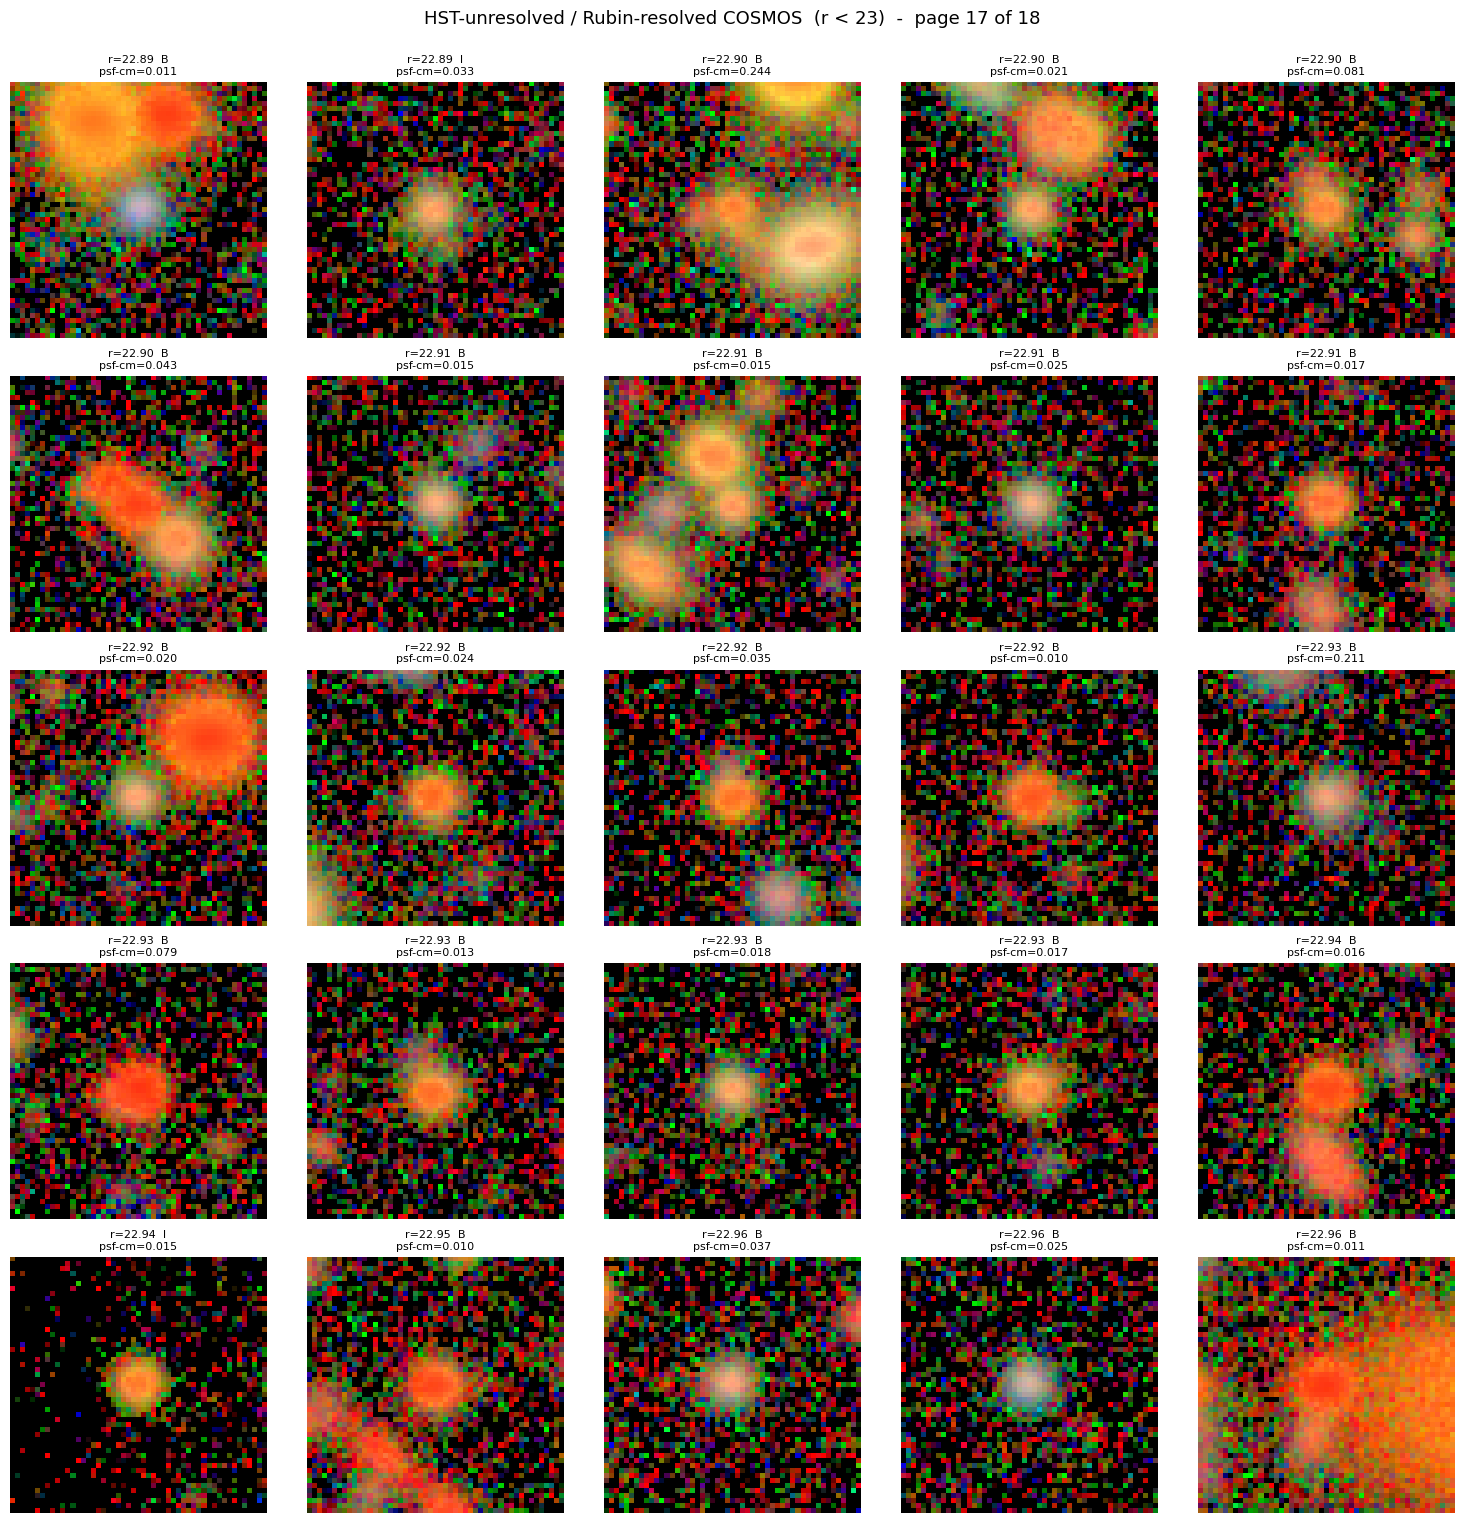

saved cutout_mosaics/mosaic_018.png


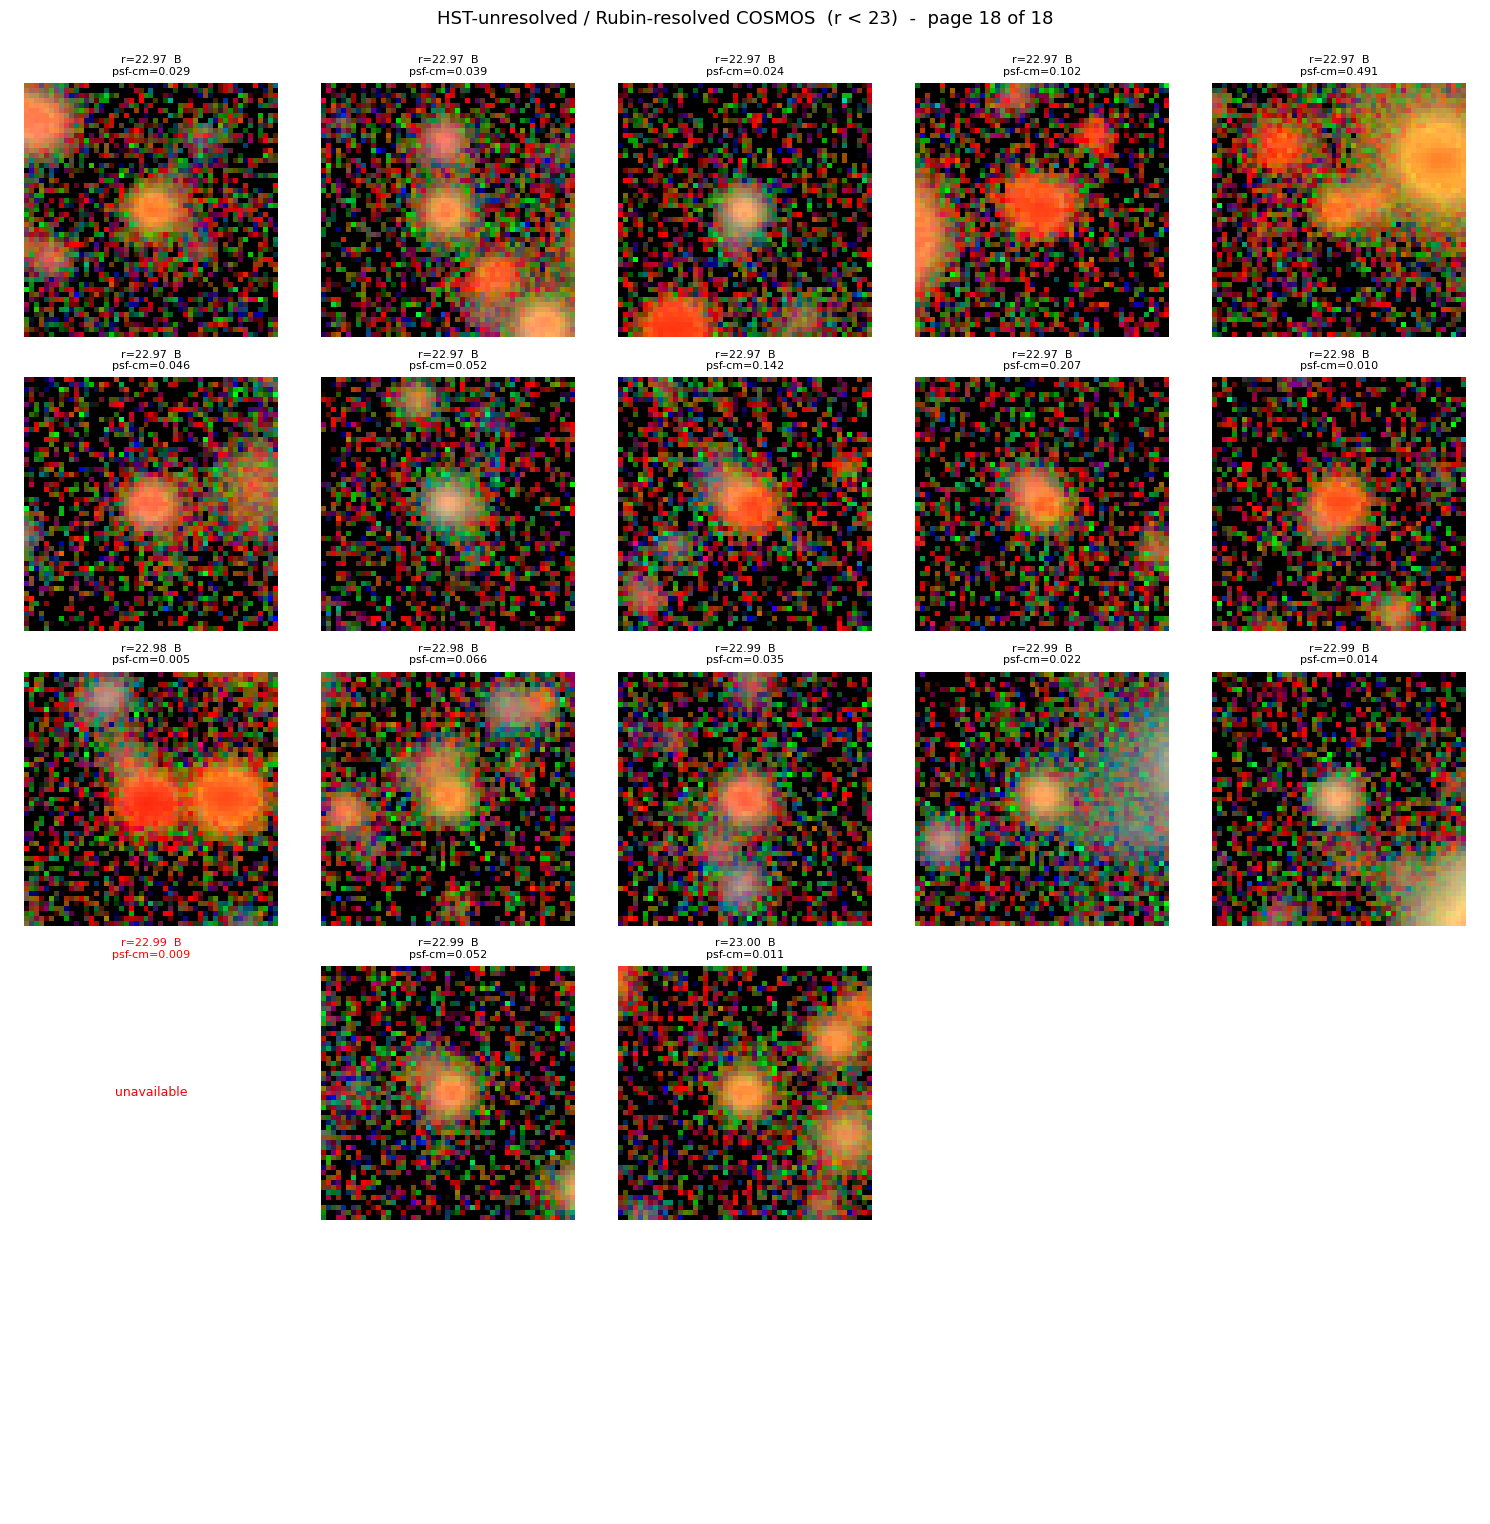


Done: 18 page(s), 5 failed cutout(s).
  788012768082025084: Failure from formatter 'lsst.images.formatters.GenericFormatter' for dataset 019ed8bf-9dd5-78b5-9c0a-b0794289c
  788013455276801030: Failure from formatter 'lsst.images.formatters.GenericFormatter' for dataset 019ed8bf-5b03-7aca-9cfa-aac90ab20
  788012149606743713: Failure from formatter 'lsst.images.formatters.GenericFormatter' for dataset 019ed8bf-9dd5-78b5-9c0a-b0794289c
  788013730154700865: Failure from formatter 'lsst.images.formatters.GenericFormatter' for dataset 019ed8bf-7a01-71d9-8934-628d40750
  788015035824765564: Failure from formatter 'lsst.images.formatters.GenericFormatter' for dataset 019ed8bf-1138-78b3-8dcf-e3ce5b552


In [7]:
def stamp_label(row):
    flags = []
    if row["detect_fromBlend"]:
        flags.append("B")
    if row["detect_isIsolated"]:
        flags.append("I")
    flag_str = "".join(flags) if flags else "-"
    return (f"r={row['r_cModelMag']:.2f}  {flag_str}\n"
            f"psf-cm={row['r_psf_minus_cModel']:.3f}")


n_pages = math.ceil(len(df) / GRID**2)
failures = []

for page in range(n_pages):
    fig, axes = plt.subplots(GRID, GRID, figsize=(15, 15.5))
    axes = np.atleast_1d(axes).flatten()

    for slot in range(GRID**2):
        ax = axes[slot]
        ax.axis("off")
        idx = page * GRID**2 + slot
        if idx >= len(df):
            continue

        row = df.iloc[idx]
        try:
            ax.imshow(get_rgb_cutout(row["RA"], row["DEC"]), origin="lower")
            ax.set_title(stamp_label(row), fontsize=8)
        except Exception as exc:
            ax.text(0.5, 0.5, "unavailable", ha="center", va="center",
                    color="red", fontsize=9, transform=ax.transAxes)
            ax.set_title(stamp_label(row), fontsize=8, color="red")
            failures.append((int(row["objectId"]), str(exc)))

    fig.suptitle(
        f"HST-unresolved / Rubin-resolved COSMOS  (r < 23)  -  page {page + 1} of {n_pages}",
        fontsize=13,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    out_path = os.path.join(OUTPUT_FOLDER, f"mosaic_{page + 1:03d}.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"saved {out_path}")
    plt.show()
    plt.close(fig)

print(f"\nDone: {n_pages} page(s), {len(failures)} failed cutout(s).")
for obj_id, msg in failures[:10]:
    print(f"  {obj_id}: {msg[:110]}")